## Setup

In [3]:
import sys, os, time
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import torch
import cmocean
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams["figure.dpi"] = 150
matplotlib.rcParams["font.family"]      = "DejaVu Sans"
matplotlib.rcParams["figure.facecolor"] = "white"
matplotlib.rcParams["axes.facecolor"]   = "white"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print(f"Device: {device}")

Device: cuda


In [4]:
from models.unet.default import Unet

def load_model(n_circles: int, epoch: int = 90) -> torch.nn.Module:
    ckpt = f"../../outputs/fm_unet/n{n_circles}/checkpoints/epoch_{epoch:04d}.pt"
    model = Unet(ch=16, ch_mul=[1, 2, 4], att_channels=[0, 0, 1], groups=8, dropout=0.0).to(device)
    state = torch.load(ckpt, map_location=device, weights_only=True)
    new_state = {k.replace("module._orig_mod.", ""): v
                 for k, v in state.items() if k != "n_averaged"}
    model.load_state_dict(new_state)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    print(f"  n={n_circles} loaded from {ckpt}")
    return model

models = {n: load_model(n) for n in [1, 2, 3, 4]}

  n=1 loaded from ../../outputs/fm_unet/n1/checkpoints/epoch_0090.pt
  n=2 loaded from ../../outputs/fm_unet/n2/checkpoints/epoch_0090.pt
  n=3 loaded from ../../outputs/fm_unet/n3/checkpoints/epoch_0090.pt
  n=4 loaded from ../../outputs/fm_unet/n4/checkpoints/epoch_0090.pt


## Forward Euler Solver and Jacobian Computation

The flow ODE is integrated with a fixed-step forward Euler scheme. The composition
$$x^T = P_{N-1}\circ \dots \circ P_0(x^0)$$
is fully differentiable in $x^0$, so `torch.func.jacrev` gives us the Jacobian
$\frac{dx^T}{dx^0}\in\mathbb{R}^{D\times D}$ with $D=64\cdot 64 = 4096$.

We use a small number of steps $N$ so the Jacobian is tractable — $N$ serves as a faithful realization of the mapping that a D-Flow optimizer differentiates through.

In [5]:
IMG_SHAPE = (1, 1, 64, 64)
D = int(np.prod(IMG_SHAPE))   # 4096
print(f"x dimension D = {D}")

N_EULER = 8          # number of Euler steps in the composed mapping
JAC_CHUNK = 512       # VJP batch size (raise if GPU memory allows, lower if OOM)


def euler_flow(x0: torch.Tensor, model: torch.nn.Module, n_steps: int) -> torch.Tensor:
    """Integrate the learned velocity field from t=0 to t=1 via forward Euler.
    x0 shape: (B, 1, 64, 64) -> returns same shape.
    """
    dt = 1.0 / n_steps
    x = x0
    for i in range(n_steps):
        t = torch.full((x.shape[0],), i * dt, device=x.device, dtype=x.dtype)
        x = x + dt * model(x, t)
    return x


def _jacobian_batched(model, x0, n_steps, chunk):
    """Row-chunked Jacobian using is_grads_batched=True (vmap-based VJP)."""
    device = x0.device
    eye = torch.eye(D, device=device)
    rows = []
    for start in range(0, D, chunk):
        end = min(start + chunk, D)
        x = x0.detach().clone().requires_grad_(True)
        y = euler_flow(x, model, n_steps).flatten()
        grads, = torch.autograd.grad(
            y, x, grad_outputs=eye[start:end], is_grads_batched=True,
            retain_graph=False, create_graph=False,
        )
        rows.append(grads.reshape(end - start, D).detach())
        del grads, y, x
    return torch.cat(rows, dim=0)


def _jacobian_loop(model, x0, n_steps):
    """Fallback: row-by-row Jacobian (slow, no vmap)."""
    x = x0.detach().clone().requires_grad_(True)
    y = euler_flow(x, model, n_steps).flatten()
    J = torch.empty((D, D), device=x.device)
    eye = torch.eye(D, device=x.device)
    for i in range(D):
        g, = torch.autograd.grad(y, x, grad_outputs=eye[i], retain_graph=(i < D - 1))
        J[i] = g.reshape(-1)
    return J


def jacobian_x0_to_xT(model: torch.nn.Module, x0: torch.Tensor,
                      n_steps: int = N_EULER, chunk: int = JAC_CHUNK) -> torch.Tensor:
    """Compute dx^T / dx^0 as a (D, D) tensor for a single sample x0 with shape (1,1,64,64)."""
    assert x0.shape == IMG_SHAPE, f"expected {IMG_SHAPE}, got {tuple(x0.shape)}"
    try:
        return _jacobian_batched(model, x0, n_steps, chunk)
    except RuntimeError as e:
        print(f"  (batched VJP failed: {type(e).__name__}: {str(e)[:120]}... falling back to row loop)")
        torch.cuda.empty_cache()
        return _jacobian_loop(model, x0, n_steps)

x dimension D = 4096


## Compute Jacobians for a Few Samples

For each model $n\in\{1,2,3,4\}$ we draw `NUM_SAMPLES` independent Gaussian seeds $x^0\sim\mathcal{N}(0,I)$, integrate the flow to obtain $x^T$, and compute the $D\times D$ Jacobian.

In [6]:
NUM_SAMPLES = 2
N_VALUES = [1, 2, 3, 4]

torch.manual_seed(123)
x0_samples = {
    n: [torch.randn(IMG_SHAPE, device=device) for _ in range(NUM_SAMPLES)]
    for n in N_VALUES
}

jacobians = {n: [] for n in N_VALUES}   # list of (D, D) cpu tensors
x_T_samples = {n: [] for n in N_VALUES} # rendered images for visualization

for n in N_VALUES:
    model = models[n]
    print(f"n={n}:")
    for k, x0 in enumerate(x0_samples[n]):
        t0 = time.time()
        with torch.no_grad():
            xT = euler_flow(x0, model, N_EULER).clamp(0, 1)
        x_T_samples[n].append(xT.squeeze().cpu())
        J = jacobian_x0_to_xT(model, x0, n_steps=N_EULER)
        jacobians[n].append(J.detach().cpu())
        print(f"  sample {k}: J shape {tuple(J.shape)}, ||J||_F={J.norm().item():.3f}, "
              f"time={time.time()-t0:.1f}s")
        del J
        torch.cuda.empty_cache()

n=1:
  sample 0: J shape (4096, 4096), ||J||_F=0.341, time=64.2s
  sample 1: J shape (4096, 4096), ||J||_F=0.291, time=63.5s
n=2:
  sample 0: J shape (4096, 4096), ||J||_F=0.158, time=63.5s
  sample 1: J shape (4096, 4096), ||J||_F=75.314, time=63.5s
n=3:
  sample 0: J shape (4096, 4096), ||J||_F=1.793, time=63.5s
  sample 1: J shape (4096, 4096), ||J||_F=0.540, time=63.5s
n=4:
  sample 0: J shape (4096, 4096), ||J||_F=5.812, time=63.5s
  sample 1: J shape (4096, 4096), ||J||_F=15.830, time=63.5s


## Singular Value Spectra

For each Jacobian compute the SVD and plot $\sigma_i$ vs index $i$ on linear and log scales.

In [7]:
singular_values = {n: [] for n in N_VALUES}

for n in N_VALUES:
    for k, J in enumerate(jacobians[n]):
        S = torch.linalg.svdvals(J.float())
        singular_values[n].append(S)
        print(f"n={n} sample {k}: sigma1={S[0].item():.4f}  "
              f"sigma_min={S[-1].item():.2e}  ||J||_F={(S**2).sum().sqrt().item():.4f}")

n=1 sample 0: sigma1=0.3154  sigma_min=2.04e-07  ||J||_F=0.3407
n=1 sample 1: sigma1=0.2498  sigma_min=2.65e-06  ||J||_F=0.2915
n=2 sample 0: sigma1=0.0922  sigma_min=3.44e-08  ||J||_F=0.1577
n=2 sample 1: sigma1=75.2343  sigma_min=2.20e-07  ||J||_F=75.3137
n=3 sample 0: sigma1=1.7858  sigma_min=8.72e-08  ||J||_F=1.7932
n=3 sample 1: sigma1=0.5047  sigma_min=1.43e-07  ||J||_F=0.5399
n=4 sample 0: sigma1=5.6796  sigma_min=2.61e-08  ||J||_F=5.8121
n=4 sample 1: sigma1=15.8288  sigma_min=2.24e-08  ||J||_F=15.8304


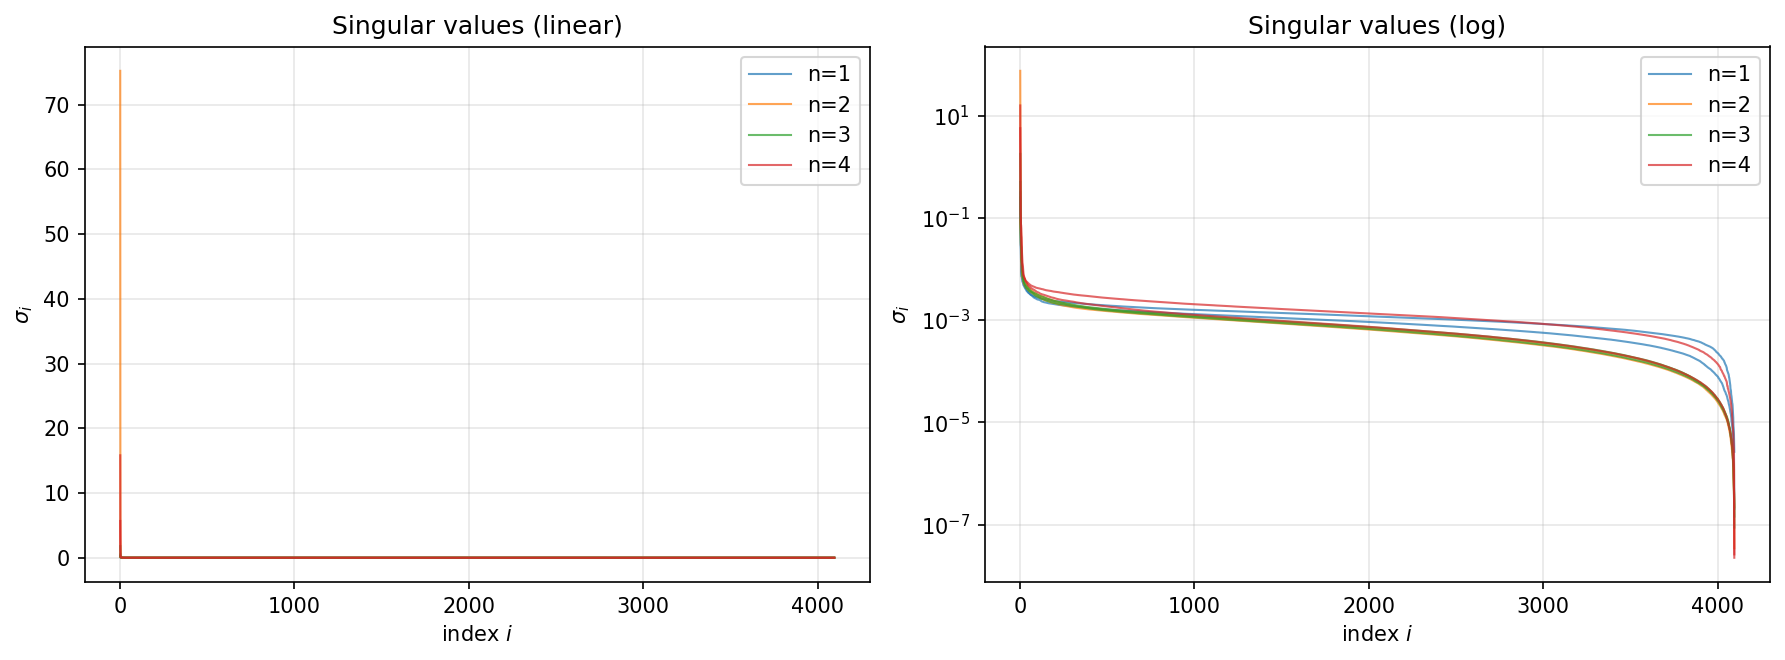

In [8]:
colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor="white")

for n in N_VALUES:
    for k, S in enumerate(singular_values[n]):
        s = S.numpy()
        idx = np.arange(1, len(s) + 1)
        label = f"n={n}" if k == 0 else None
        axes[0].plot(idx, s, color=colors[n], alpha=0.7, lw=1.0, label=label)
        axes[1].plot(idx, s, color=colors[n], alpha=0.7, lw=1.0, label=label)

for ax in axes:
    ax.set_xlabel("index $i$")
    ax.set_ylabel(r"$\sigma_i$")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_title("Singular values (linear)")
axes[1].set_yscale("log")
axes[1].set_title("Singular values (log)")

plt.tight_layout()
plt.show()

## Generated Samples

The corresponding $x^T$ rendered for each $(n, \text{sample})$.

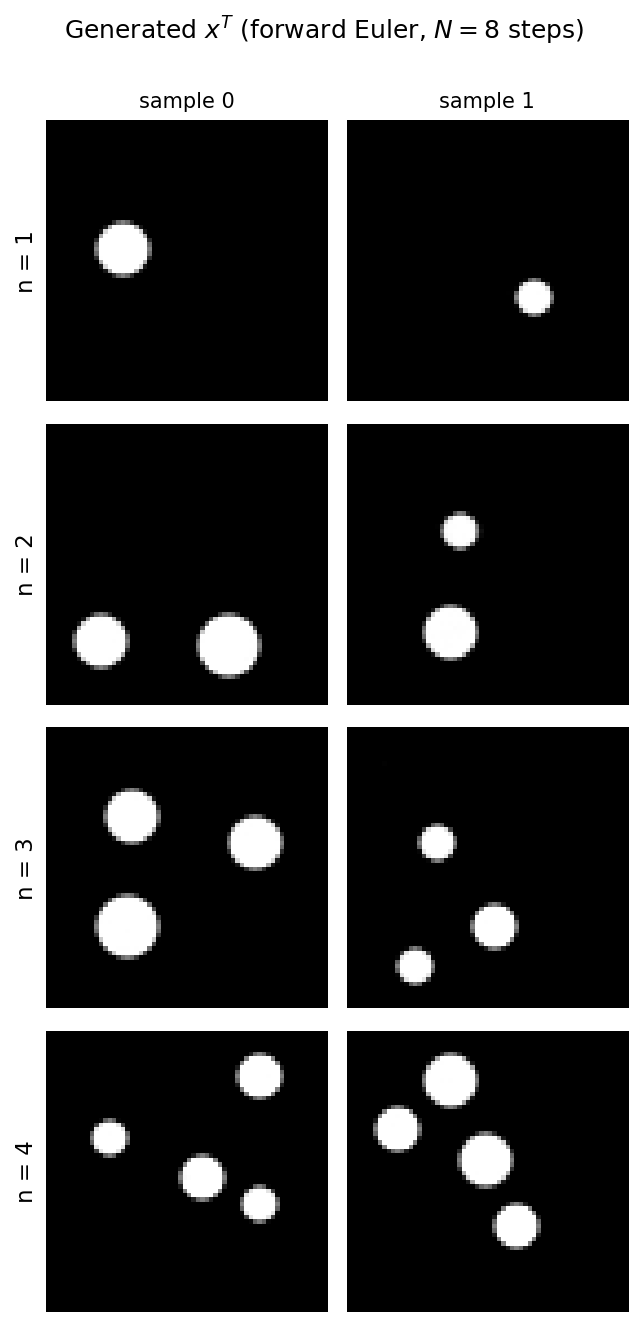

In [ ]:
fig, axes = plt.subplots(len(N_VALUES), NUM_SAMPLES,
                         figsize=(2.2 * NUM_SAMPLES, 2.2 * len(N_VALUES)),
                         facecolor="white")
if len(N_VALUES) == 1:
    axes = np.array([axes])
if NUM_SAMPLES == 1:
    axes = axes[:, None]

for i, n in enumerate(N_VALUES):
    for k in range(NUM_SAMPLES):
        ax = axes[i, k]
        ax.imshow(x_T_samples[n][k].numpy(), cmap=cmocean.cmap.dense_r, vmin=0, vmax=1,
                  interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)
        if k == 0:
            ax.set_ylabel(f"n = {n}", fontsize=11)
        if i == 0:
            ax.set_title(f"sample {k}", fontsize=10)

fig.suptitle(rf"Generated $x^T$ (forward Euler, $N={N_EULER}$ steps)", y=1)
plt.tight_layout()
plt.show()

## Per-Step Jacobian Decomposition

In [10]:
NUM_SAMPLES_STEP = 3

def single_euler_step(model, x, t_scalar, dt):
    t = torch.full((x.shape[0],), t_scalar, device=x.device, dtype=x.dtype)
    return x + dt * model(x, t)


def jacobian_single_step(model, x, t_scalar, dt, chunk=JAC_CHUNK):
    eye = torch.eye(D, device=x.device)
    rows = []
    for start in range(0, D, chunk):
        end = min(start + chunk, D)
        x_in = x.detach().clone().requires_grad_(True)
        y = single_euler_step(model, x_in, t_scalar, dt).flatten()
        grads, = torch.autograd.grad(
            y, x_in, grad_outputs=eye[start:end],
            is_grads_batched=True, retain_graph=False,
        )
        rows.append(grads.reshape(end - start, D).detach())
        del grads, y, x_in
    return torch.cat(rows, dim=0)


def compute_per_step_jacobians(model, x0, n_steps):
    """Returns per-step Jacobians J_i, cumulative products J_{<=k}, and intermediate states."""
    dt = 1.0 / n_steps
    step_jacs = []
    cumul_jacs = []
    xs = []

    x = x0.detach().clone()
    cumul = None

    for i in range(n_steps):
        t_i = i * dt
        xs.append(x.clone())

        Ji = jacobian_single_step(model, x, t_i, dt)
        step_jacs.append(Ji.cpu())

        if cumul is None:
            cumul = Ji.cpu()
        else:
            cumul = Ji.cpu() @ cumul
        cumul_jacs.append(cumul.clone())

        with torch.no_grad():
            x = single_euler_step(model, x, t_i, dt)

    return step_jacs, cumul_jacs, xs

In [11]:
torch.manual_seed(123)
x0_step_samples = {
    n: [torch.randn(IMG_SHAPE, device=device) for _ in range(NUM_SAMPLES_STEP)]
    for n in N_VALUES
}

# step_svs[n][k][i] = singular values of cumulative Jacobian at step i
step_svs = {n: [] for n in N_VALUES}
# per_step_svs[n][k][i] = singular values of individual J_i
per_step_svs = {n: [] for n in N_VALUES}

for n in N_VALUES:
    model = models[n]
    print(f"n={n}:")
    for k in range(NUM_SAMPLES_STEP):
        x0 = x0_step_samples[n][k]
        t0 = time.time()
        step_jacs, cumul_jacs, _ = compute_per_step_jacobians(model, x0, N_EULER)

        svs_cumul = [torch.linalg.svdvals(J.float()) for J in cumul_jacs]
        svs_step  = [torch.linalg.svdvals(J.float()) for J in step_jacs]
        step_svs[n].append(svs_cumul)
        per_step_svs[n].append(svs_step)

        elapsed = time.time() - t0
        print(f"  sample {k}: {elapsed:.1f}s  "
              f"sigma1(final)={svs_cumul[-1][0].item():.4f}  "
              f"sigma_min(final)={svs_cumul[-1][-1].item():.2e}")
        del step_jacs, cumul_jacs
        torch.cuda.empty_cache()

n=1:
  sample 0: 96.9s  sigma1(final)=0.3154  sigma_min(final)=2.06e-07
  sample 1: 96.8s  sigma1(final)=0.2498  sigma_min(final)=2.65e-06
  sample 2: 96.5s  sigma1(final)=0.6198  sigma_min(final)=2.91e-08
n=2:
  sample 0: 96.3s  sigma1(final)=75.2349  sigma_min(final)=2.07e-07
  sample 1: 94.8s  sigma1(final)=0.1740  sigma_min(final)=6.14e-09
  sample 2: 96.4s  sigma1(final)=0.3668  sigma_min(final)=5.32e-08
n=3:
  sample 0: 96.0s  sigma1(final)=22.7725  sigma_min(final)=2.91e-07
  sample 1: 96.0s  sigma1(final)=0.2766  sigma_min(final)=1.21e-07
  sample 2: 95.7s  sigma1(final)=0.7122  sigma_min(final)=2.44e-08
n=4:
  sample 0: 96.4s  sigma1(final)=15.9778  sigma_min(final)=7.05e-07
  sample 1: 96.2s  sigma1(final)=0.7909  sigma_min(final)=3.46e-08
  sample 2: 95.1s  sigma1(final)=107.1578  sigma_min(final)=1.69e-08


## Cumulative Jacobian Singular Values per Timestep

Each subplot shows one sample. Lines are colored by timestep $k$ (darker = later in the flow). The spectrum of $J_{\leq k}$ shows how the mapping's rank structure builds up step by step.

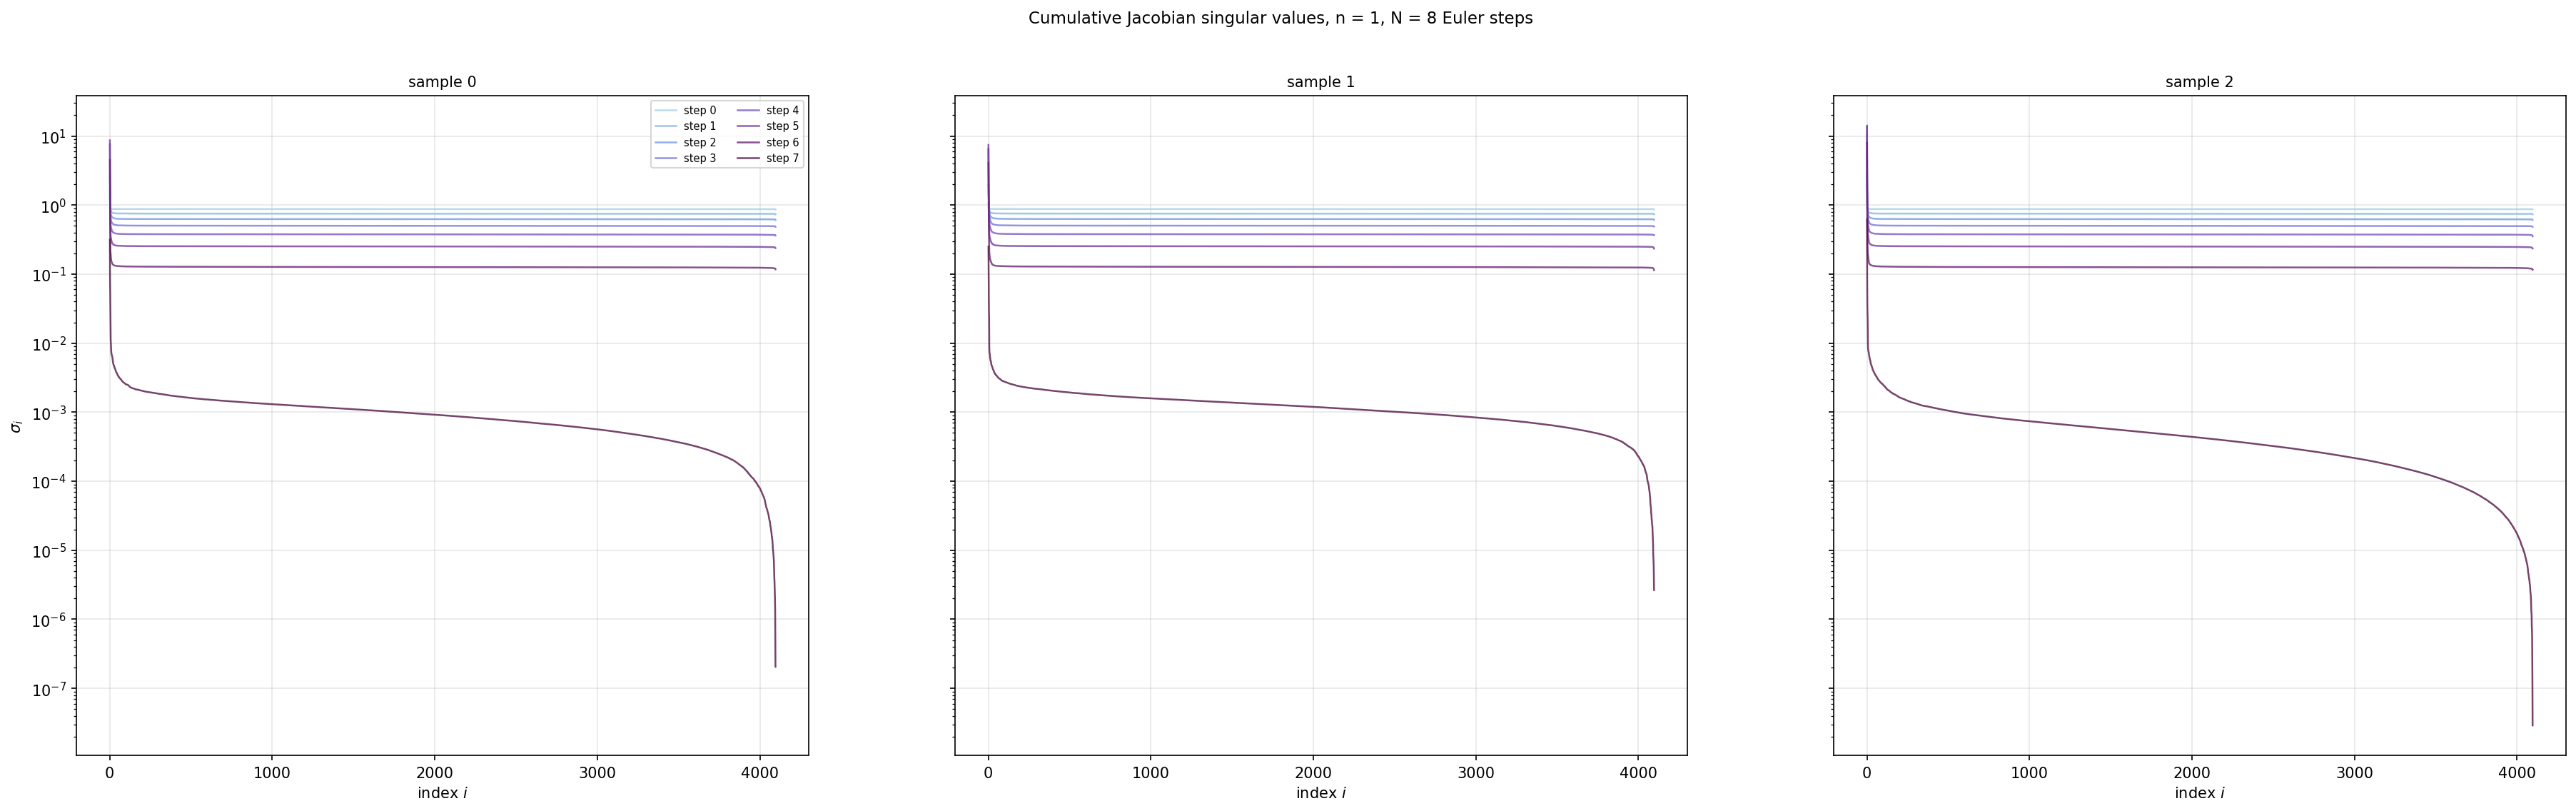

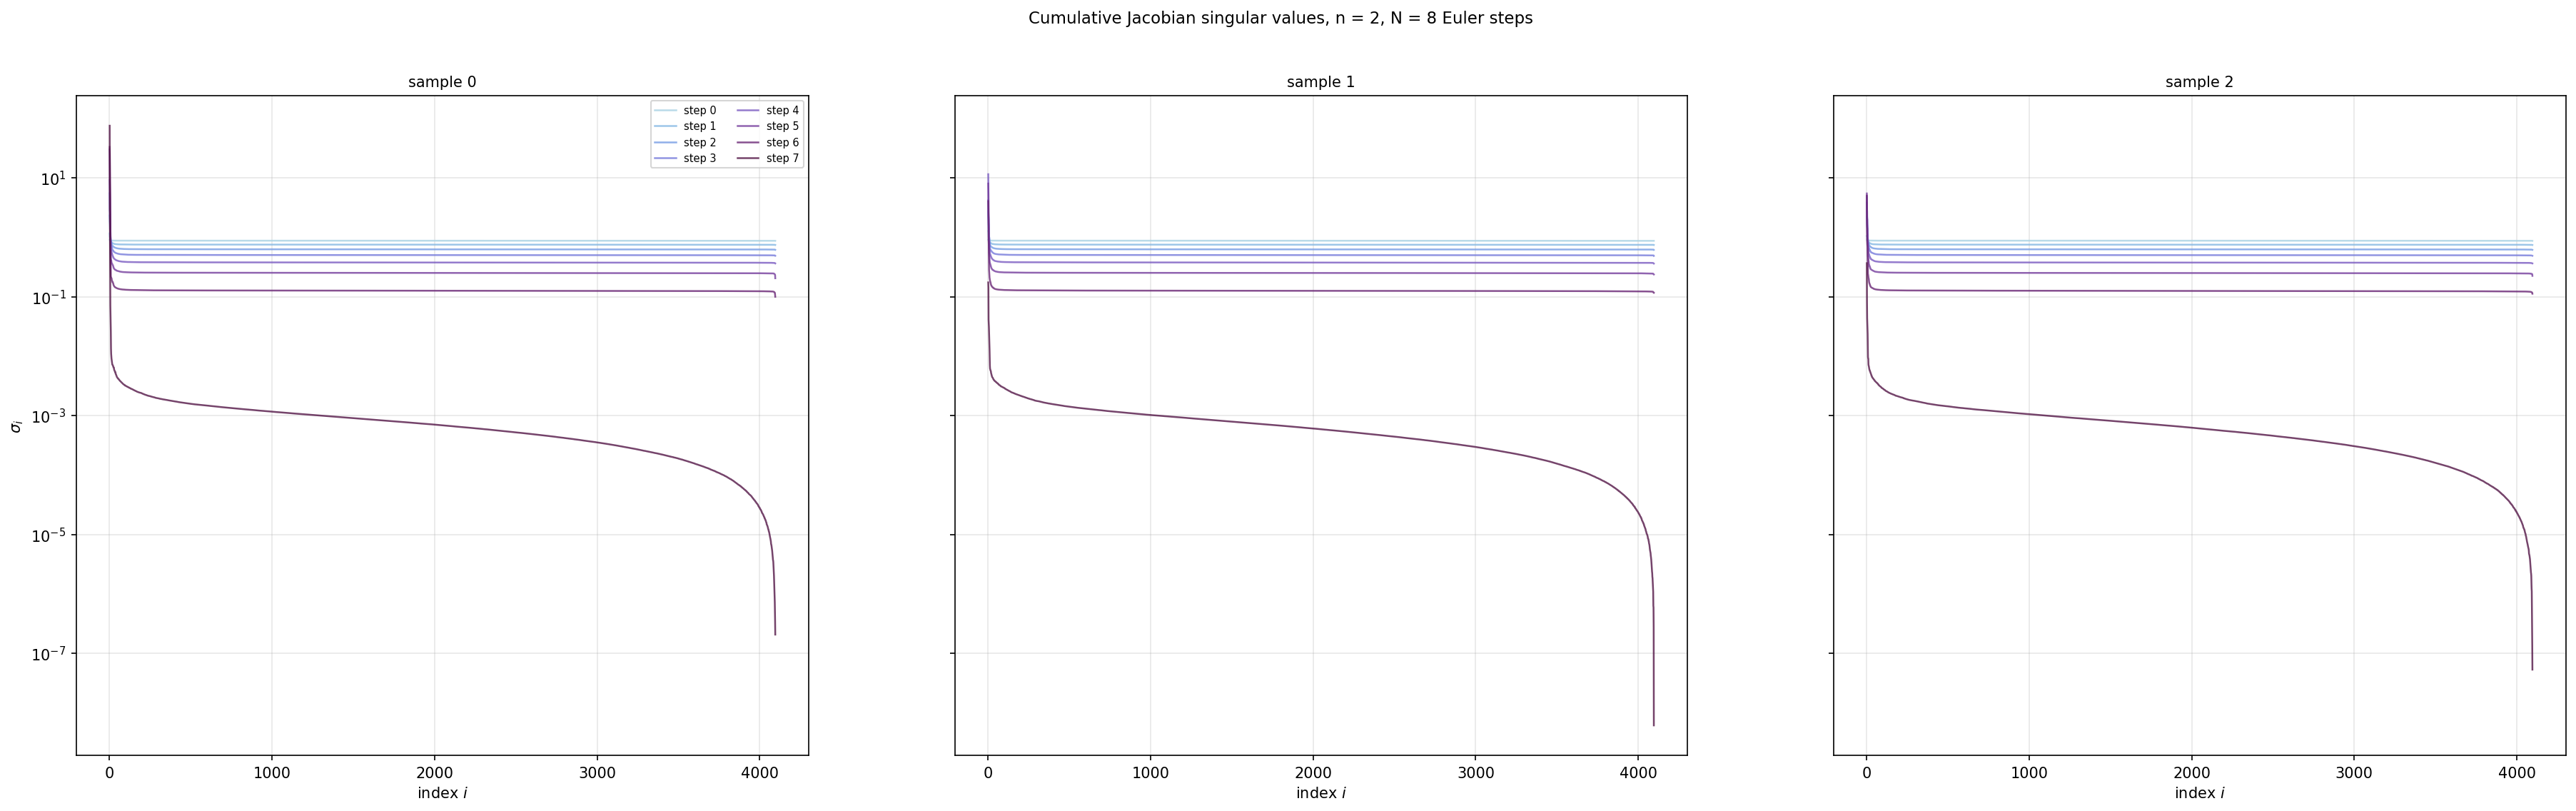

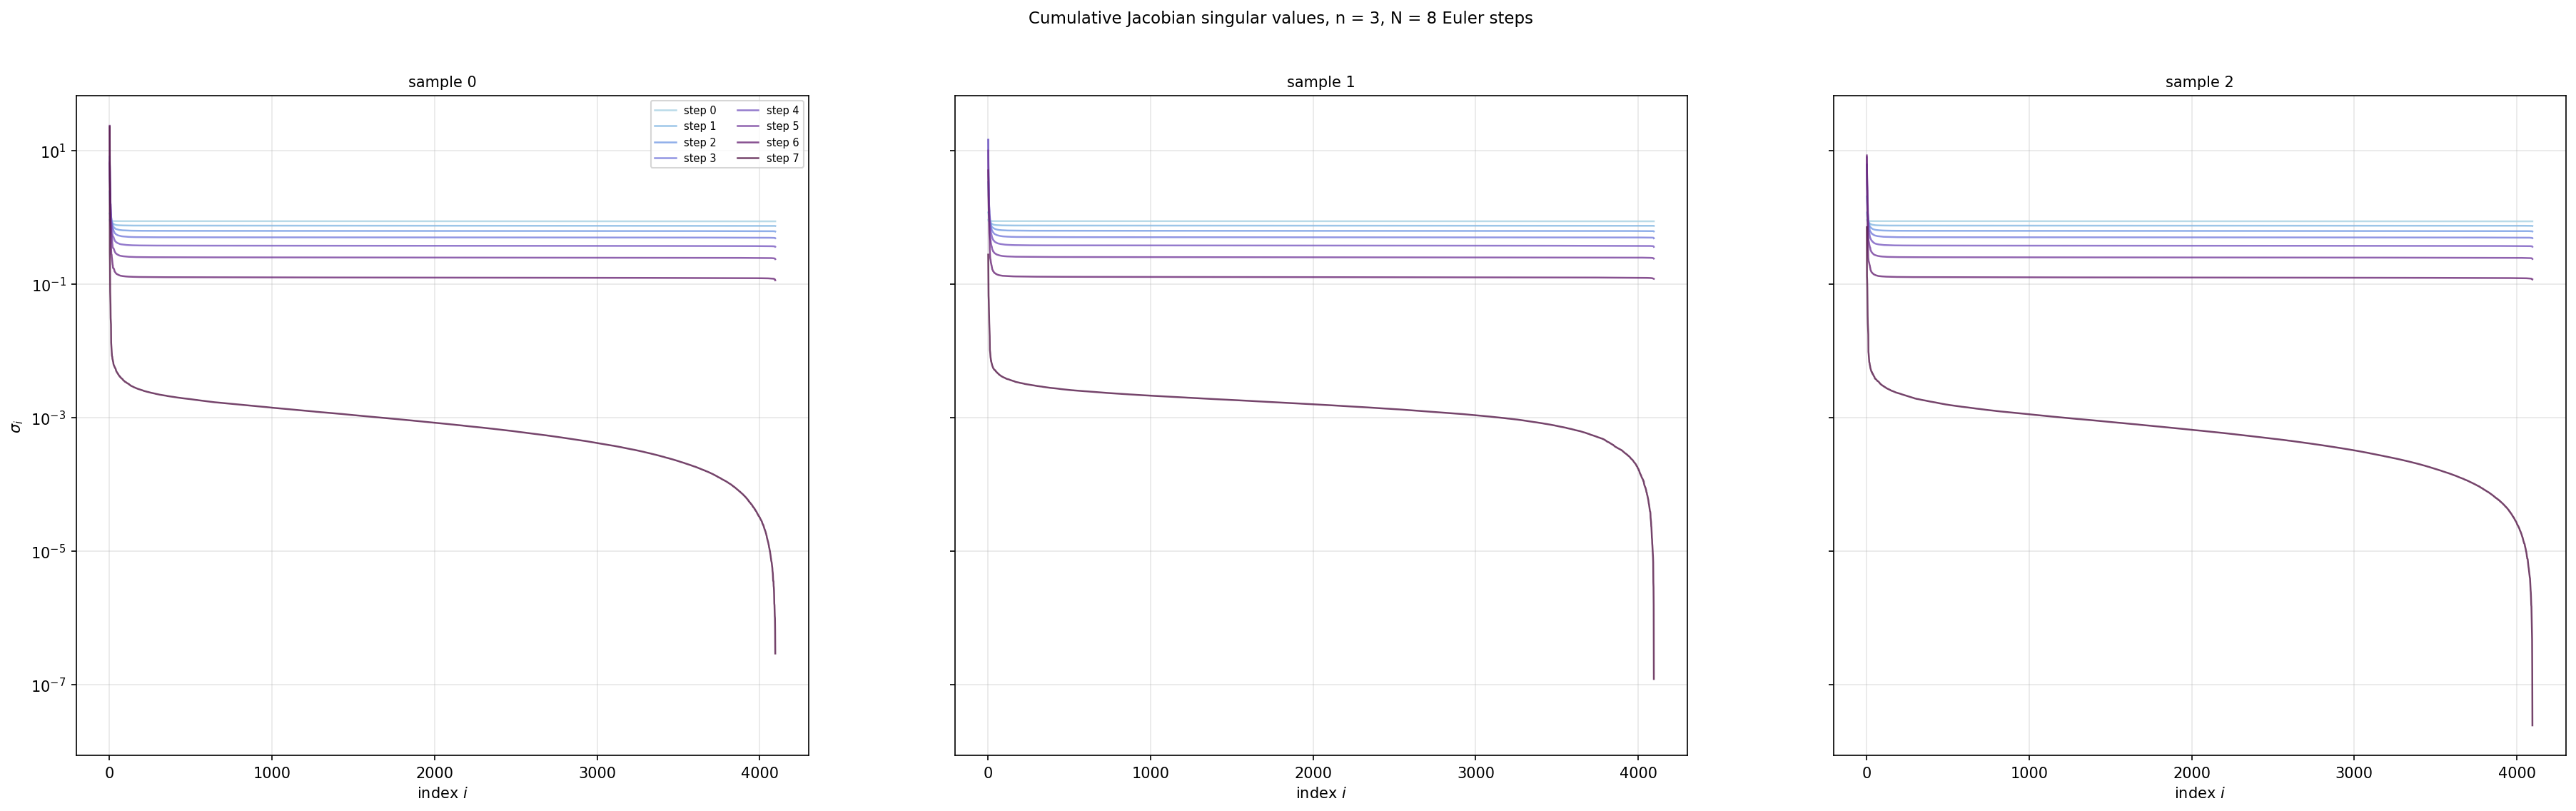

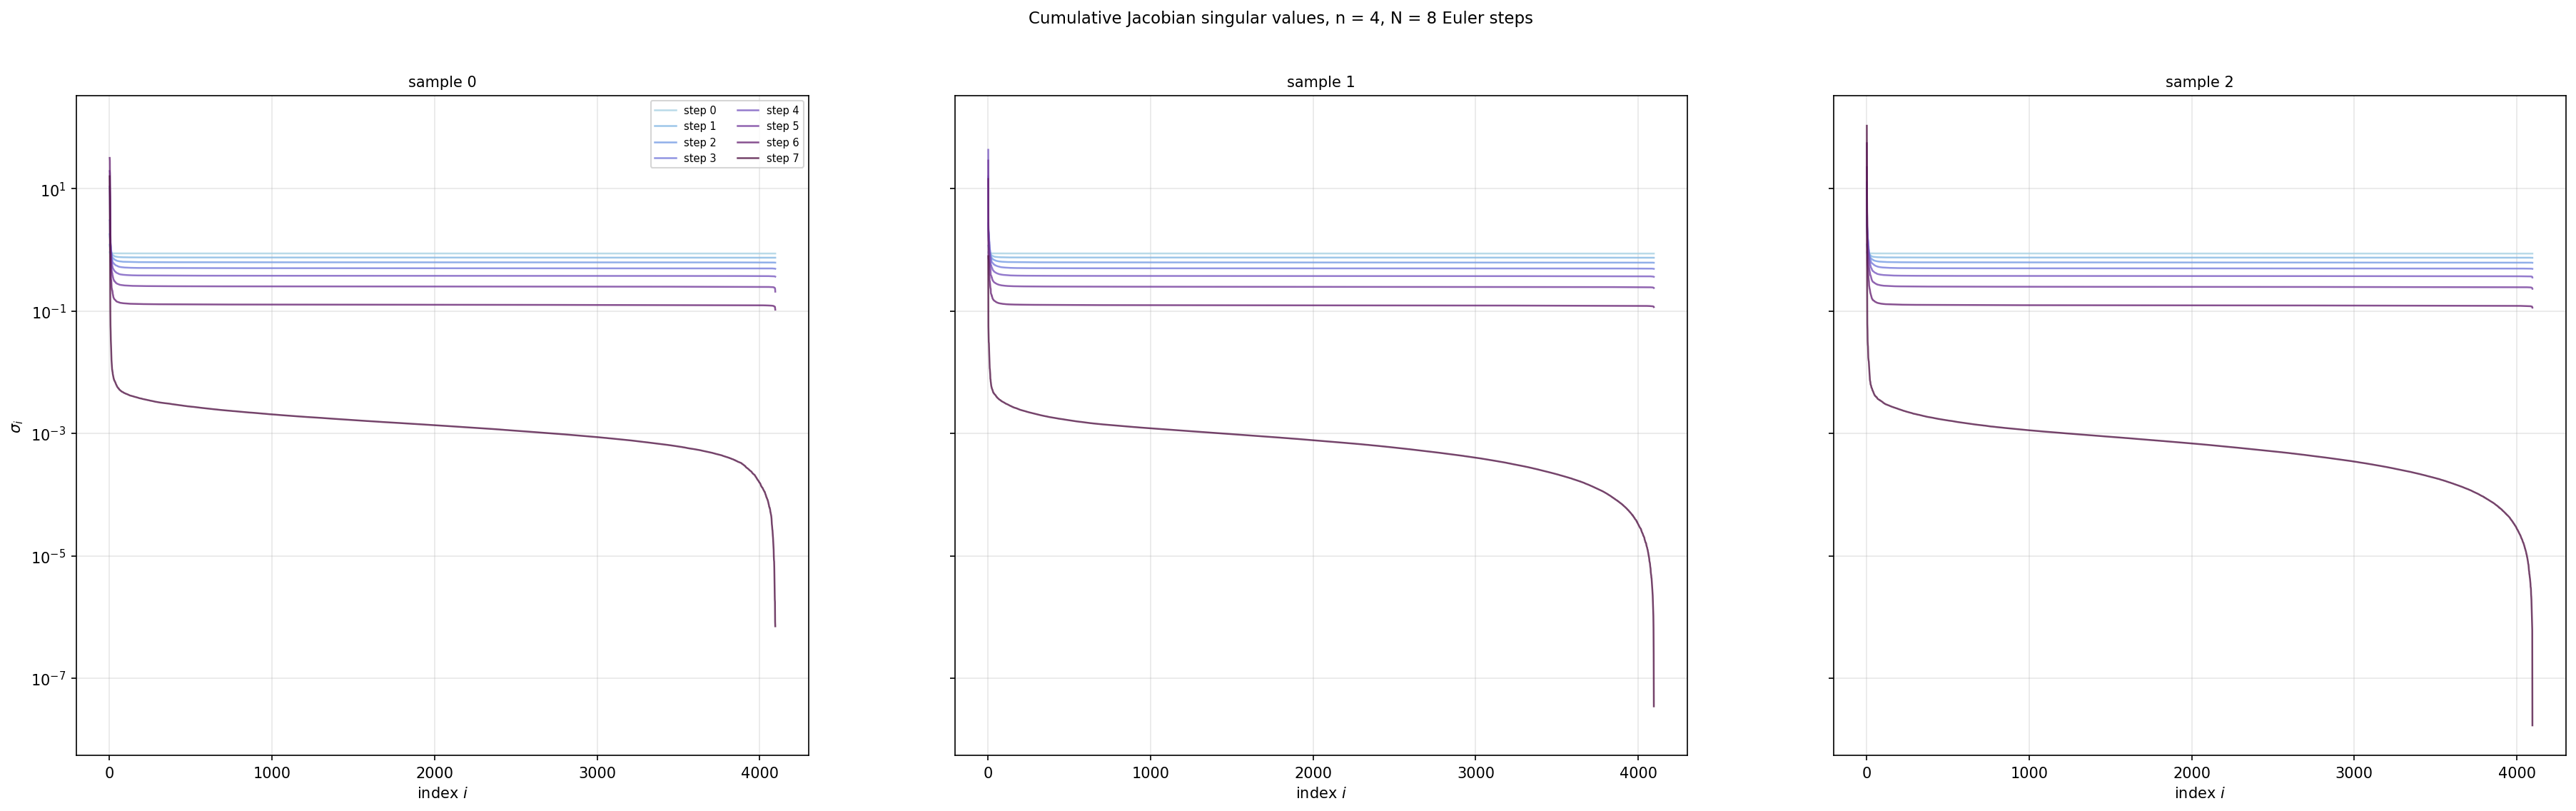

In [18]:
for n in N_VALUES:
    fig, axes = plt.subplots(1, NUM_SAMPLES_STEP, figsize=(10 * NUM_SAMPLES_STEP, 8),
                             facecolor="white", sharey=True)
    if NUM_SAMPLES_STEP == 1:
        axes = [axes]

    cmap_steps = cmocean.cm.dense

    for k in range(NUM_SAMPLES_STEP):
        ax = axes[k]
        for i, S in enumerate(step_svs[n][k]):
            s = S.numpy()
            color = cmap_steps(0.15 + 0.75 * i / (N_EULER - 1))
            ax.semilogy(np.arange(1, len(s) + 1), s, color=color, alpha=0.8, lw=1.2,
                        label=f"step {i}" if k == 0 else None)
        ax.set_xlabel("index $i$")
        if k == 0:
            ax.set_ylabel(r"$\sigma_i$")
        ax.set_title(f"sample {k}", fontsize=10)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

    if NUM_SAMPLES_STEP > 0:
        axes[0].legend(fontsize=7, ncol=2, loc="upper right")

    fig.suptitle(f"Cumulative Jacobian singular values, n = {n}, "
                 f"N = {N_EULER} Euler steps", fontsize=11)

    plt.show()

## Singular Value Histograms per Timestep

Histograms of the singular values of $J_{\leq k}$ at each timestep, showing how the distribution shifts as the flow progresses.

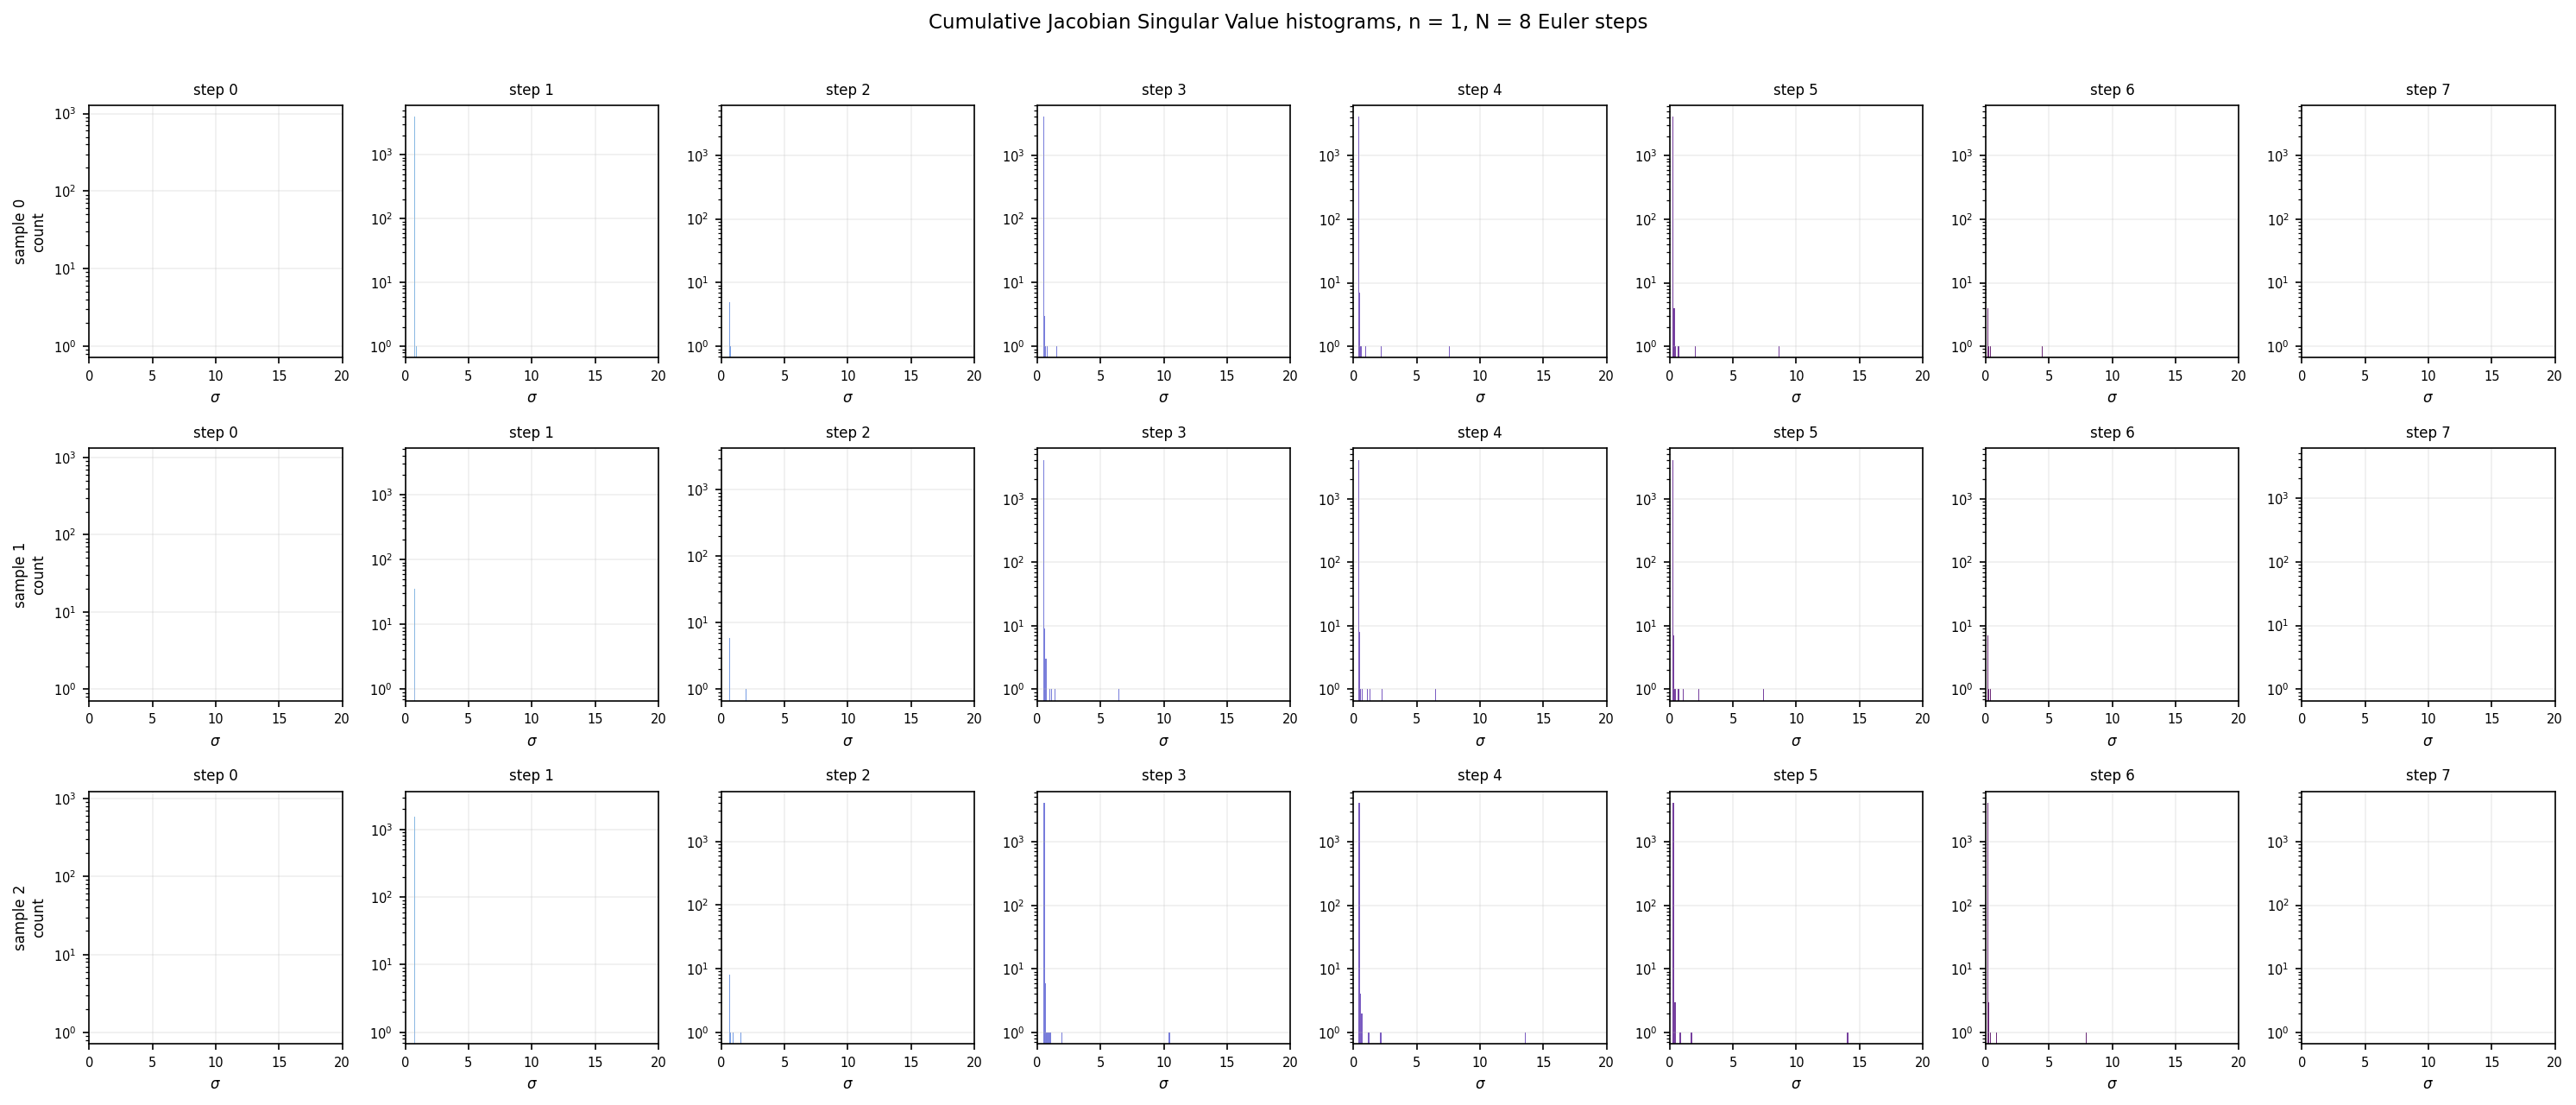

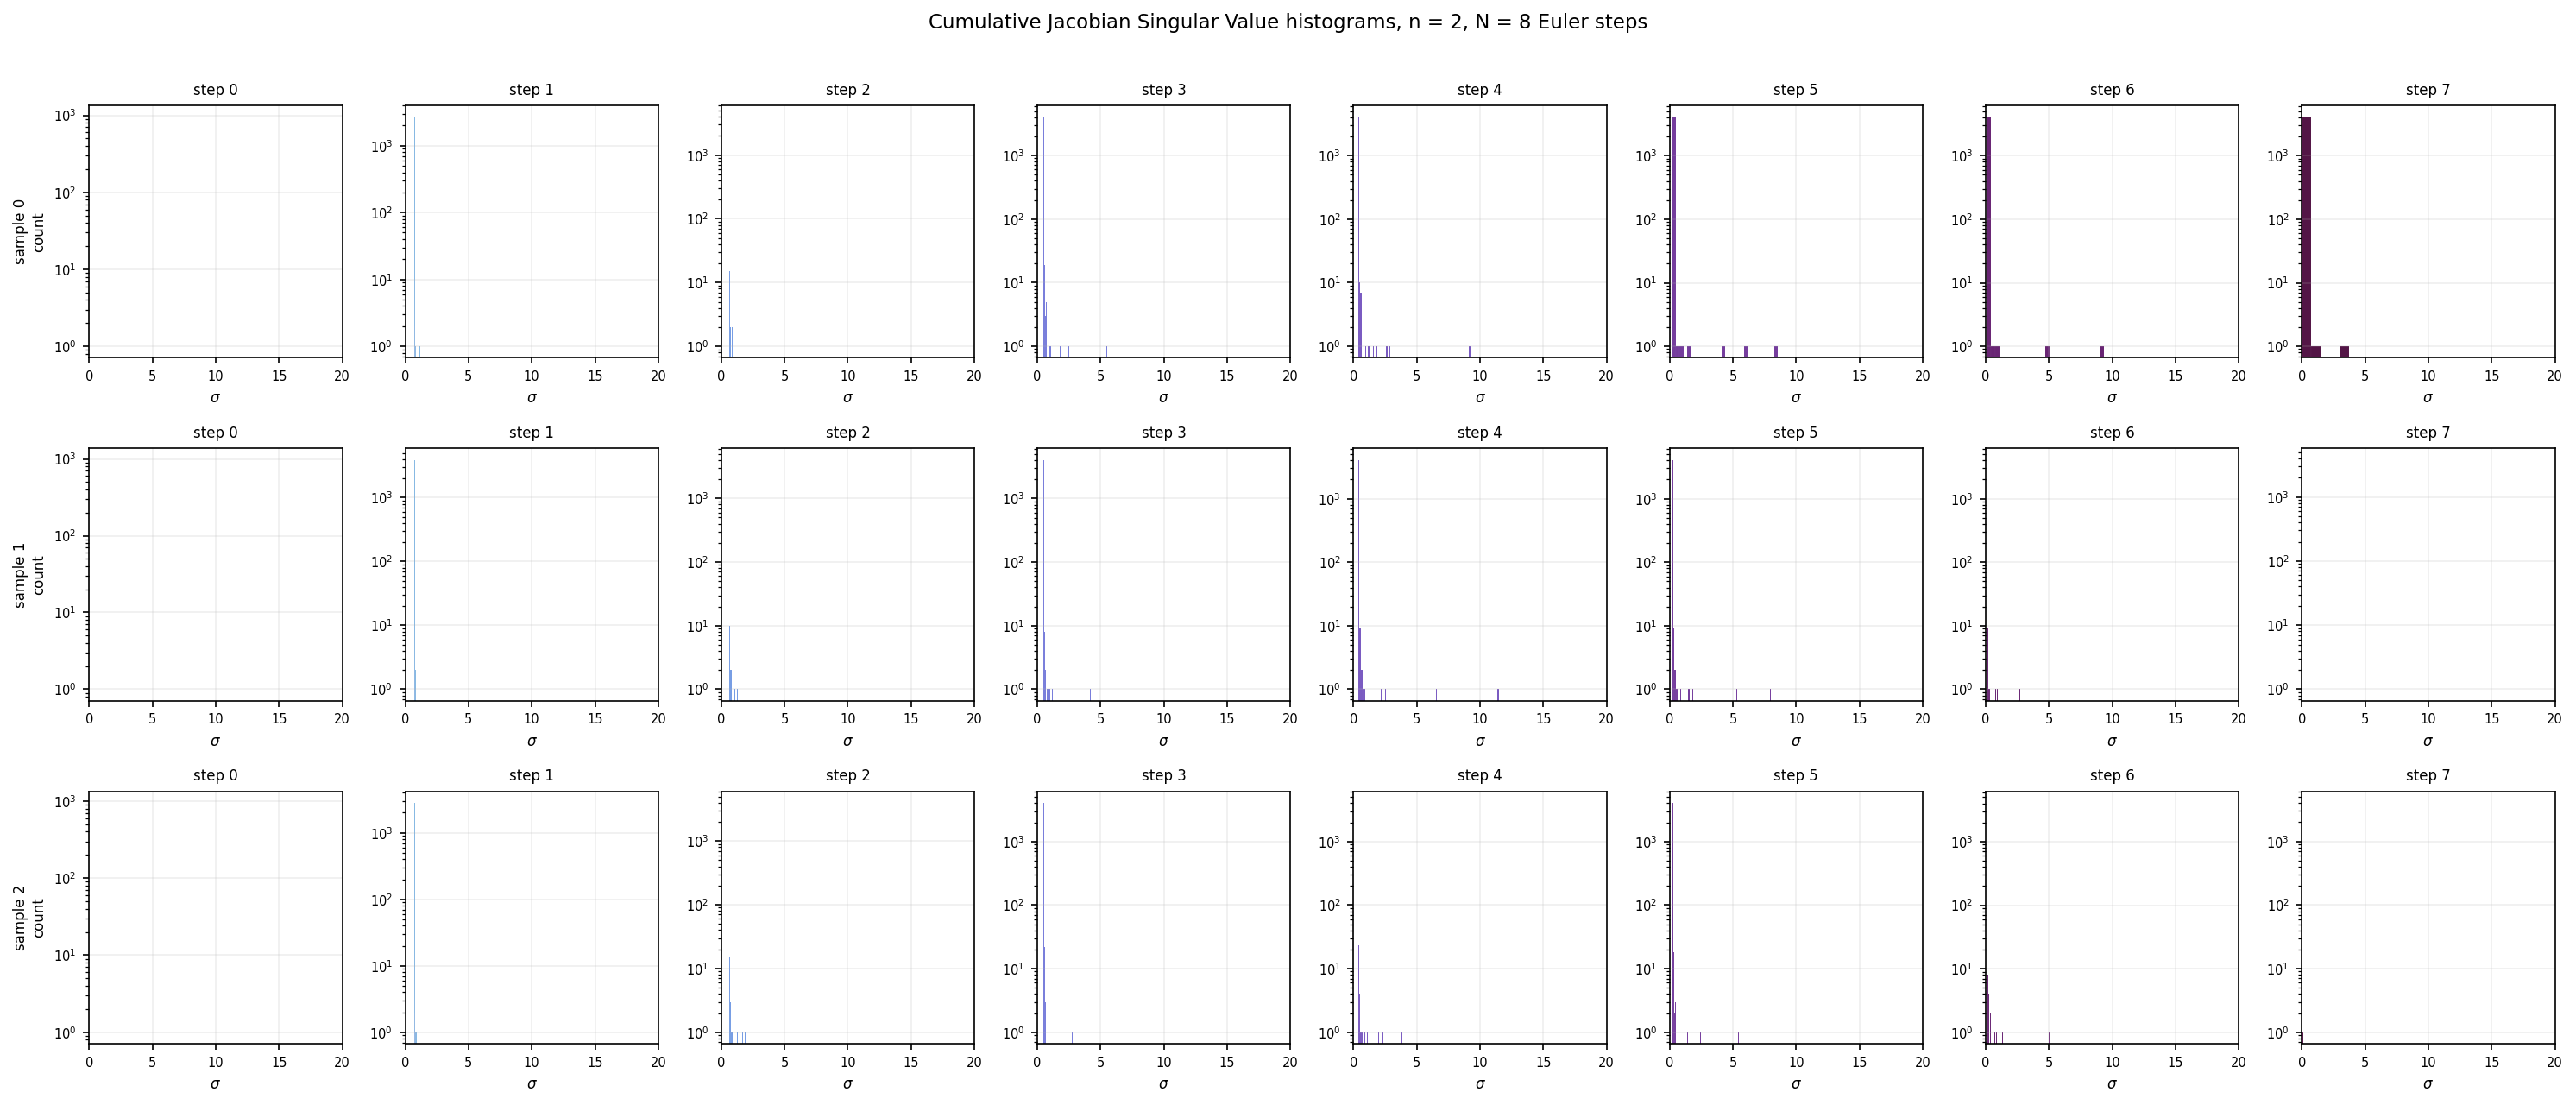

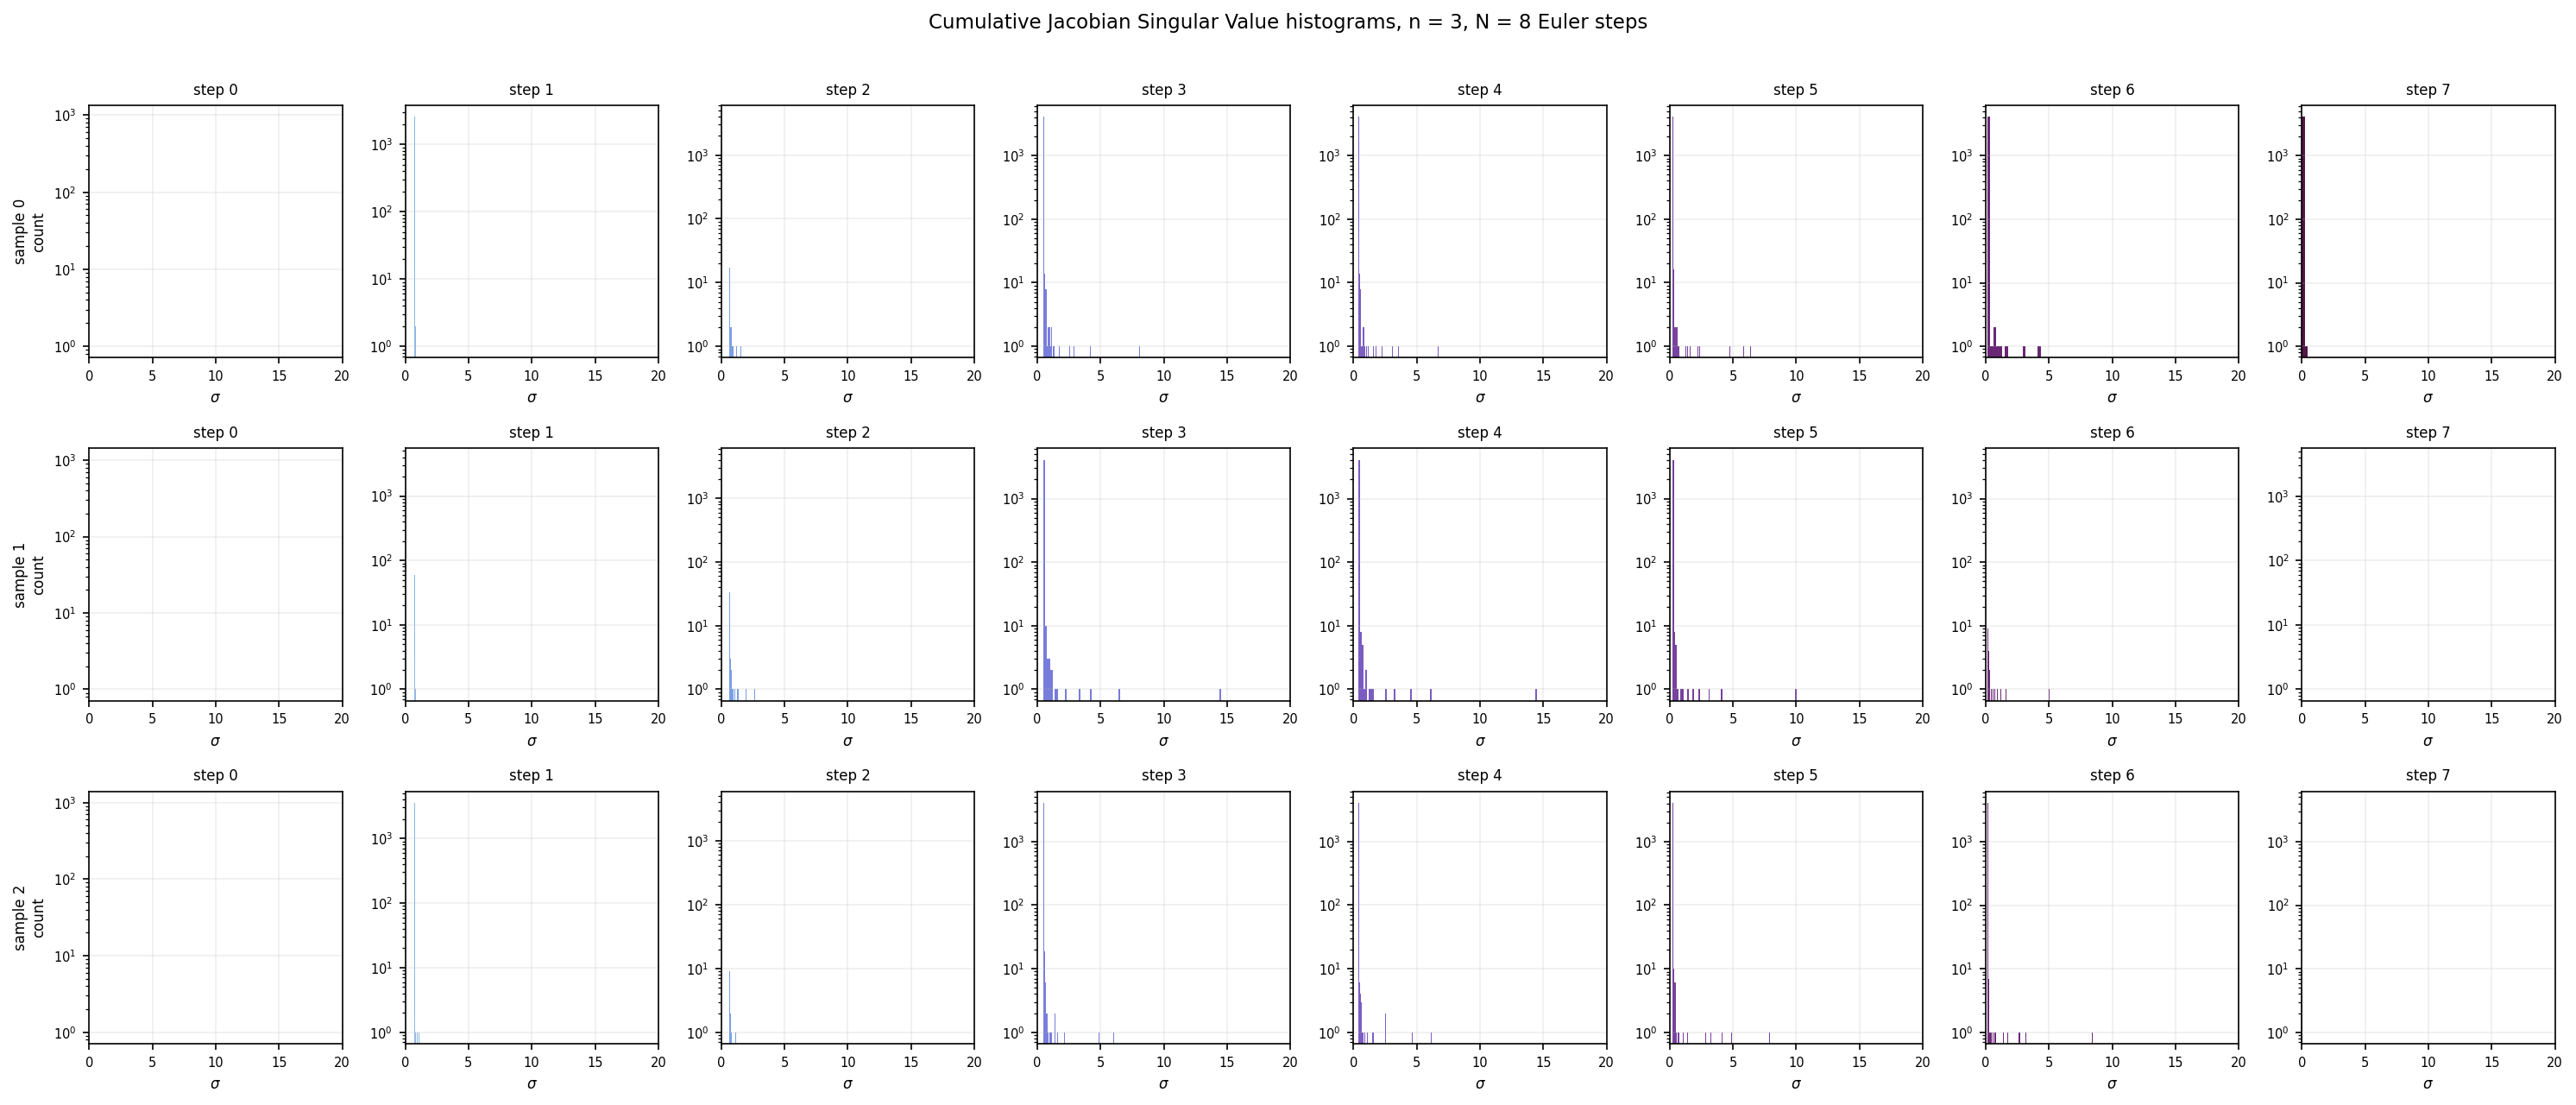

KeyboardInterrupt: 

In [27]:
for n in N_VALUES:
    fig, axes = plt.subplots(NUM_SAMPLES_STEP, N_EULER,
                             figsize=(2.5 * N_EULER, 2.8 * NUM_SAMPLES_STEP),
                             facecolor="white")
    if NUM_SAMPLES_STEP == 1:
        axes = axes[np.newaxis, :]

    cmap_steps = cmocean.cm.dense

    for k in range(NUM_SAMPLES_STEP):
        for i in range(N_EULER):
            ax = axes[k, i]
            s = step_svs[n][k][i].numpy()
            color = cmap_steps(0.15 + 0.75 * i / (N_EULER - 1))
            ax.hist(s, bins=100, color=color, edgecolor="white", linewidth=0.01, alpha=1)
            ax.set_yscale("log")
            ax.set_xlabel(r"$\sigma$", fontsize=8)
            ax.set_xlim(0, 20)
            if i == 0:
                ax.set_ylabel(f"sample {k}\ncount", fontsize=8)
            ax.set_title(f"step {i}", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.2)

    fig.suptitle(f"Cumulative Jacobian Singular Value histograms, n = {n}, "
                 f"N = {N_EULER} Euler steps", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

## Individual Per-Step Jacobian Singular Values

Singular values of each $J_i = I + \Delta t \cdot \frac{\partial v_\theta}{\partial x}\big|_{x^i, t_i}$ individually. Values near 1 mean the step is nearly isometric; $\sigma < 1$ is contractive, $\sigma > 1$ is expanding.

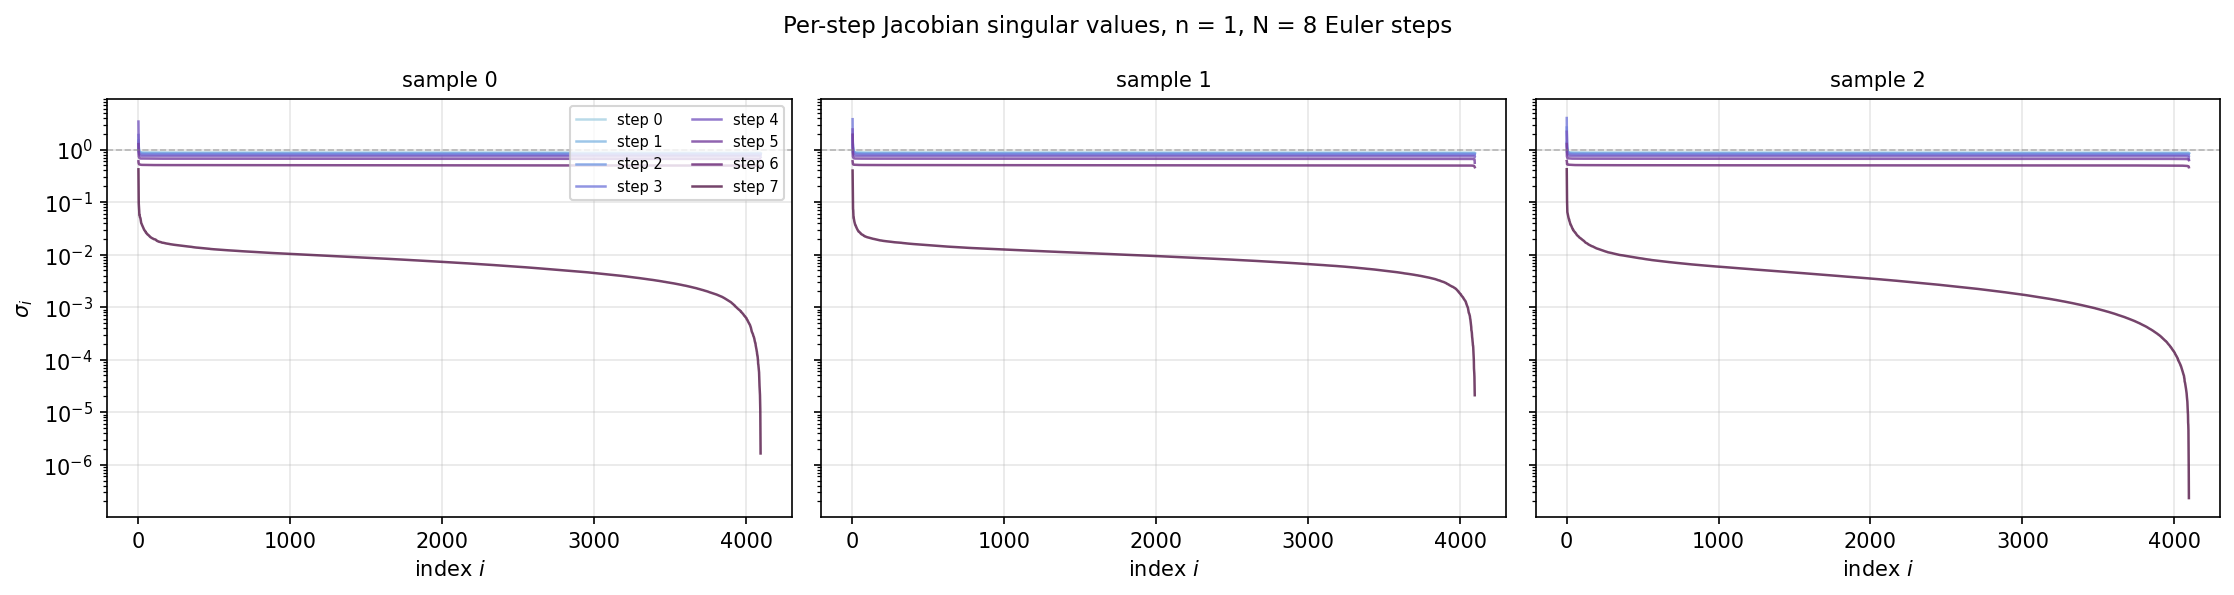

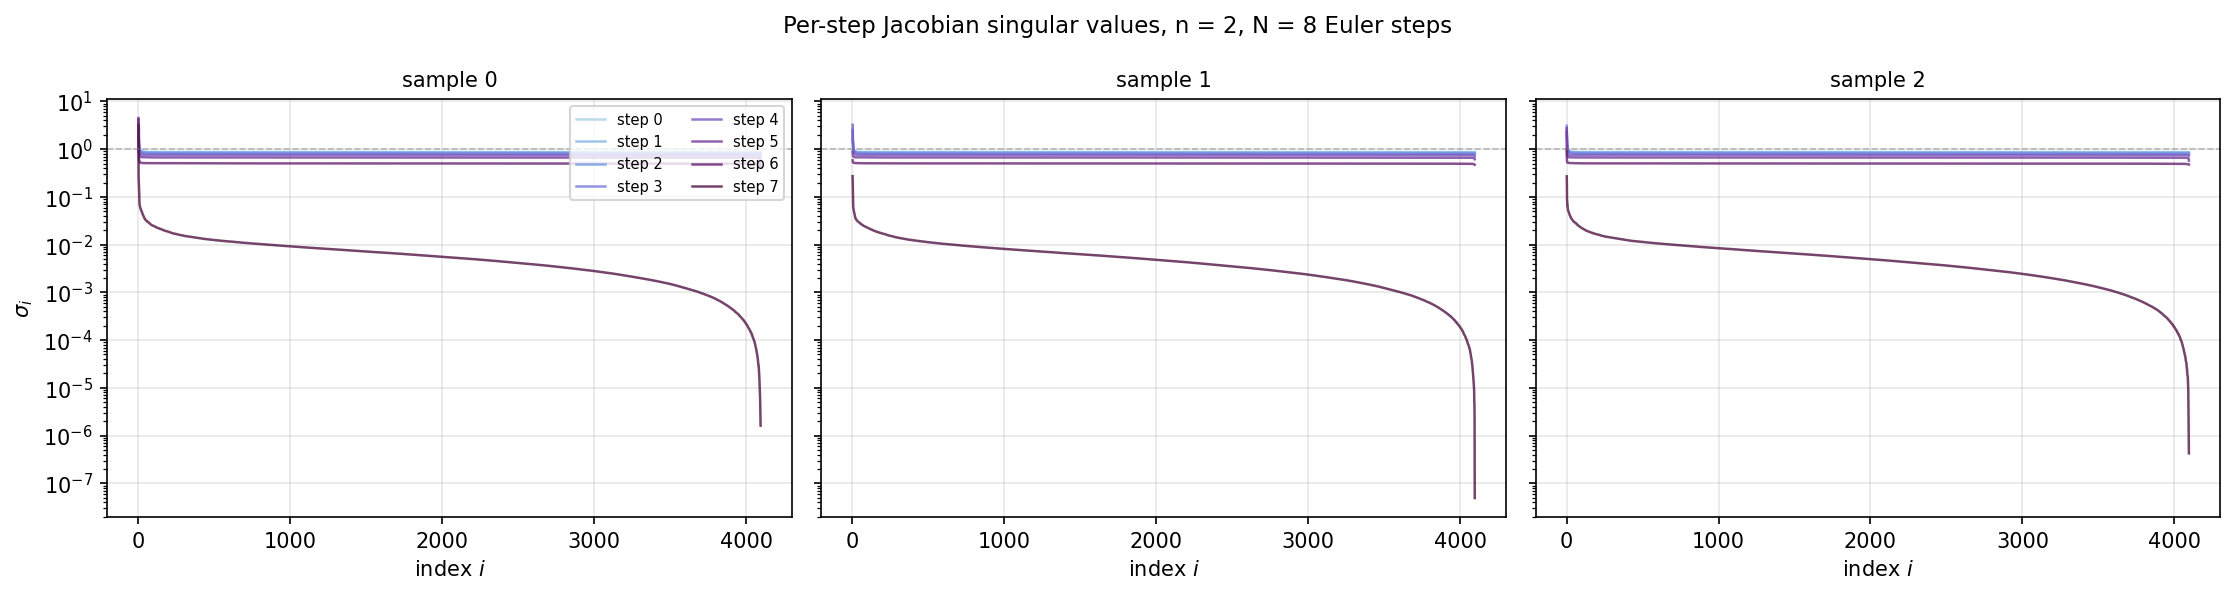

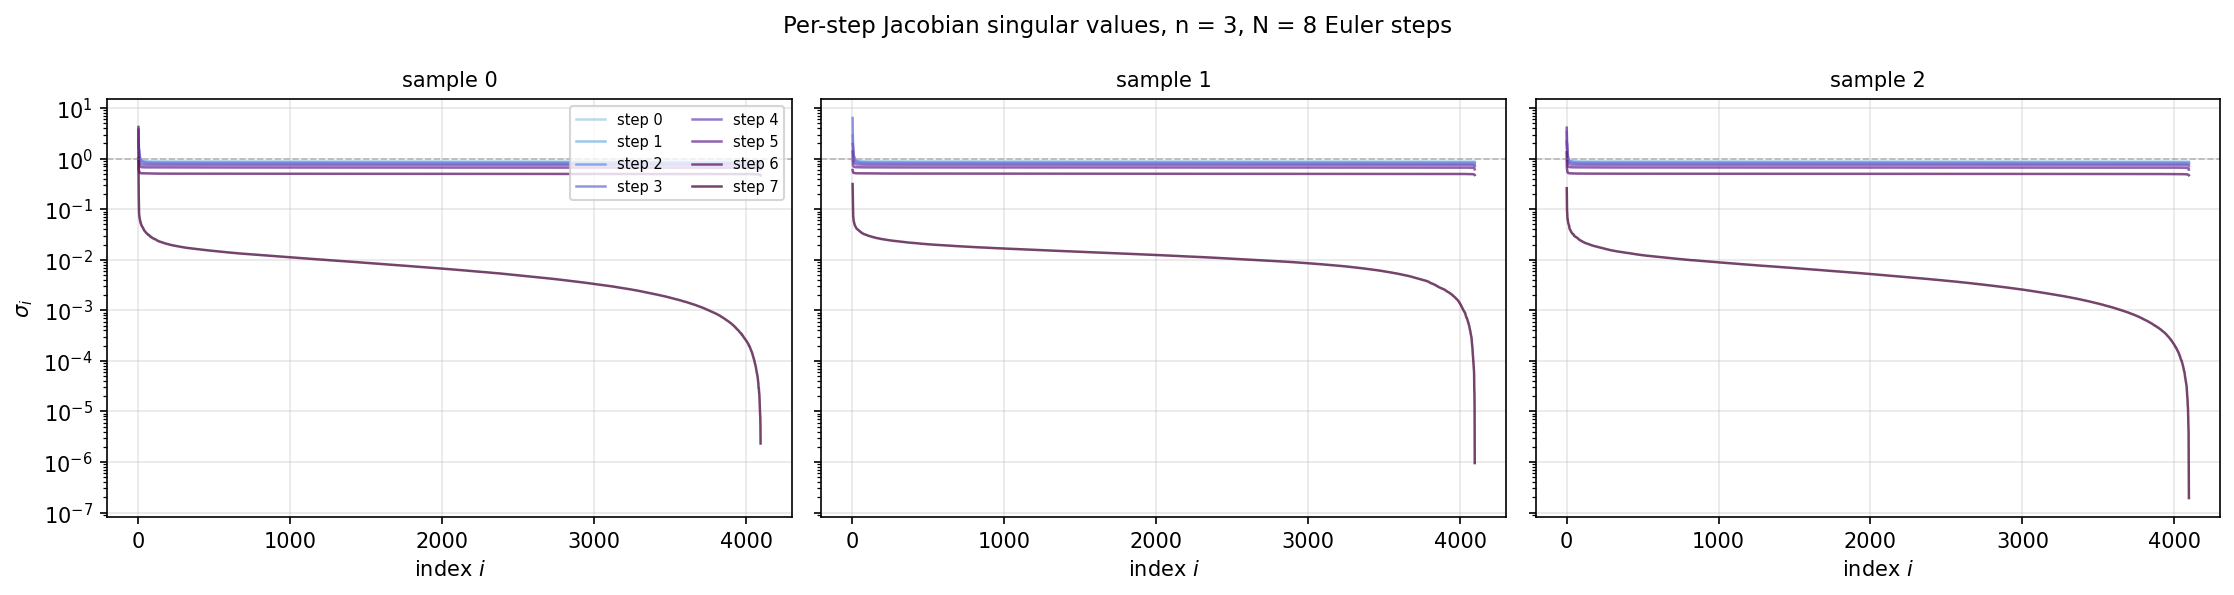

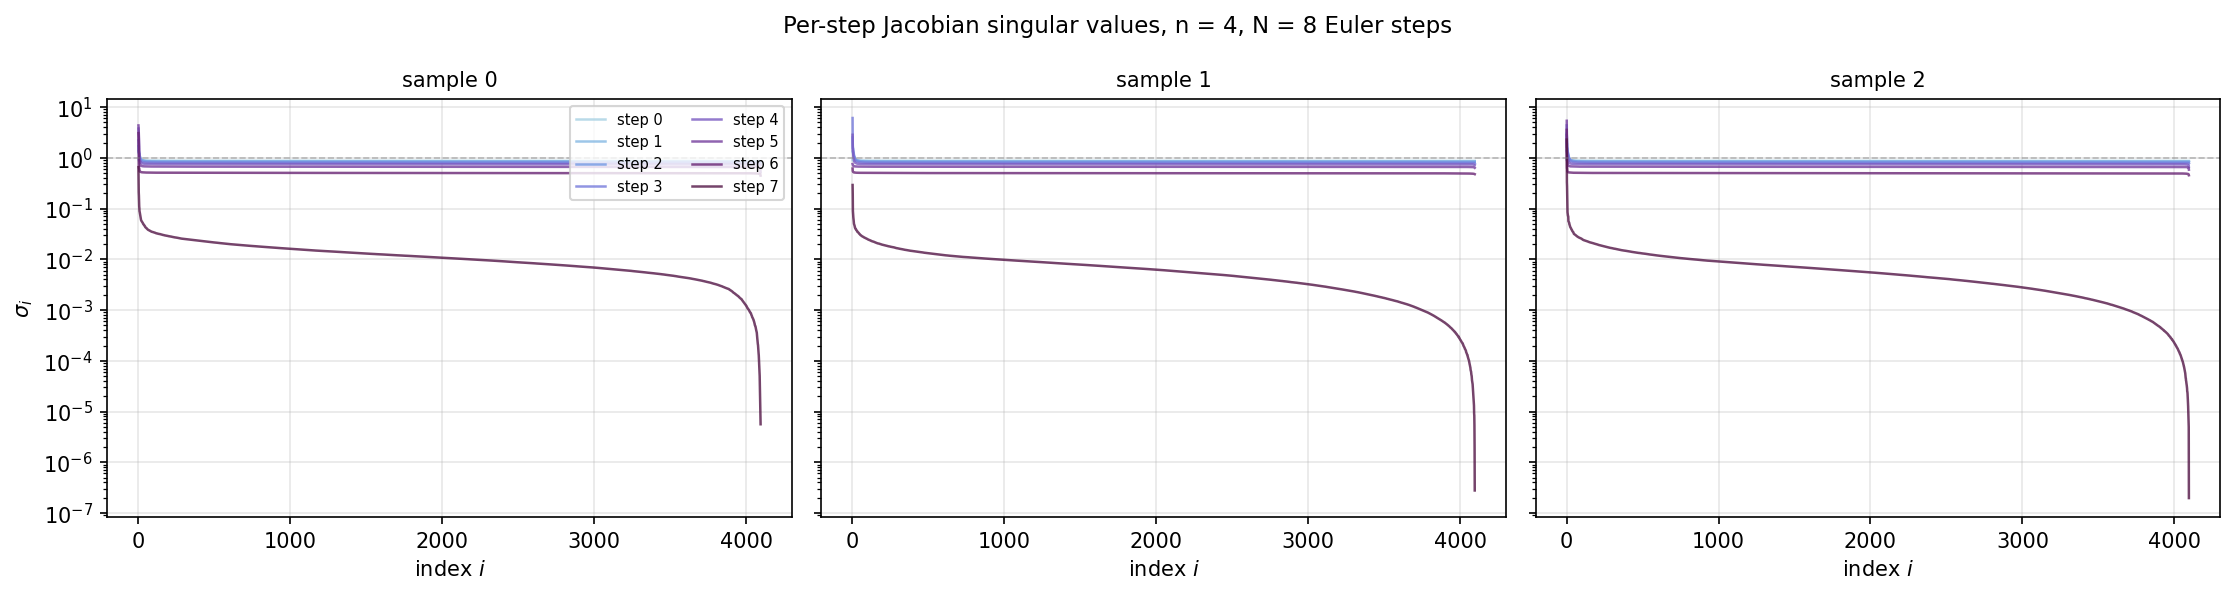

In [14]:
for n in N_VALUES:
    fig, axes = plt.subplots(1, NUM_SAMPLES_STEP, figsize=(5 * NUM_SAMPLES_STEP, 4),
                             facecolor="white", sharey=True)
    if NUM_SAMPLES_STEP == 1:
        axes = [axes]

    cmap_steps = cmocean.cm.dense

    for k in range(NUM_SAMPLES_STEP):
        ax = axes[k]
        for i, S in enumerate(per_step_svs[n][k]):
            s = S.numpy()
            color = cmap_steps(0.15 + 0.75 * i / (N_EULER - 1))
            ax.semilogy(np.arange(1, len(s) + 1), s, color=color, alpha=0.8, lw=1.2,
                        label=f"step {i}" if k == 0 else None)
        ax.axhline(1.0, color="gray", ls="--", lw=0.8, alpha=0.5)
        ax.set_xlabel("index $i$")
        if k == 0:
            ax.set_ylabel(r"$\sigma_i$")
        ax.set_title(f"sample {k}", fontsize=10)
        ax.grid(True, alpha=0.3)

    if NUM_SAMPLES_STEP > 0:
        axes[0].legend(fontsize=7, ncol=2, loc="upper right")

    fig.suptitle(f"Per-step Jacobian singular values, n = {n}, "
                 f"N = {N_EULER} Euler steps", fontsize=11)
    plt.tight_layout()
    plt.show()

## Per-Step Jacobian Singular Value Histograms

Histograms of individual $J_i$ singular values. A distribution centered near 1 means the step is nearly isometric.

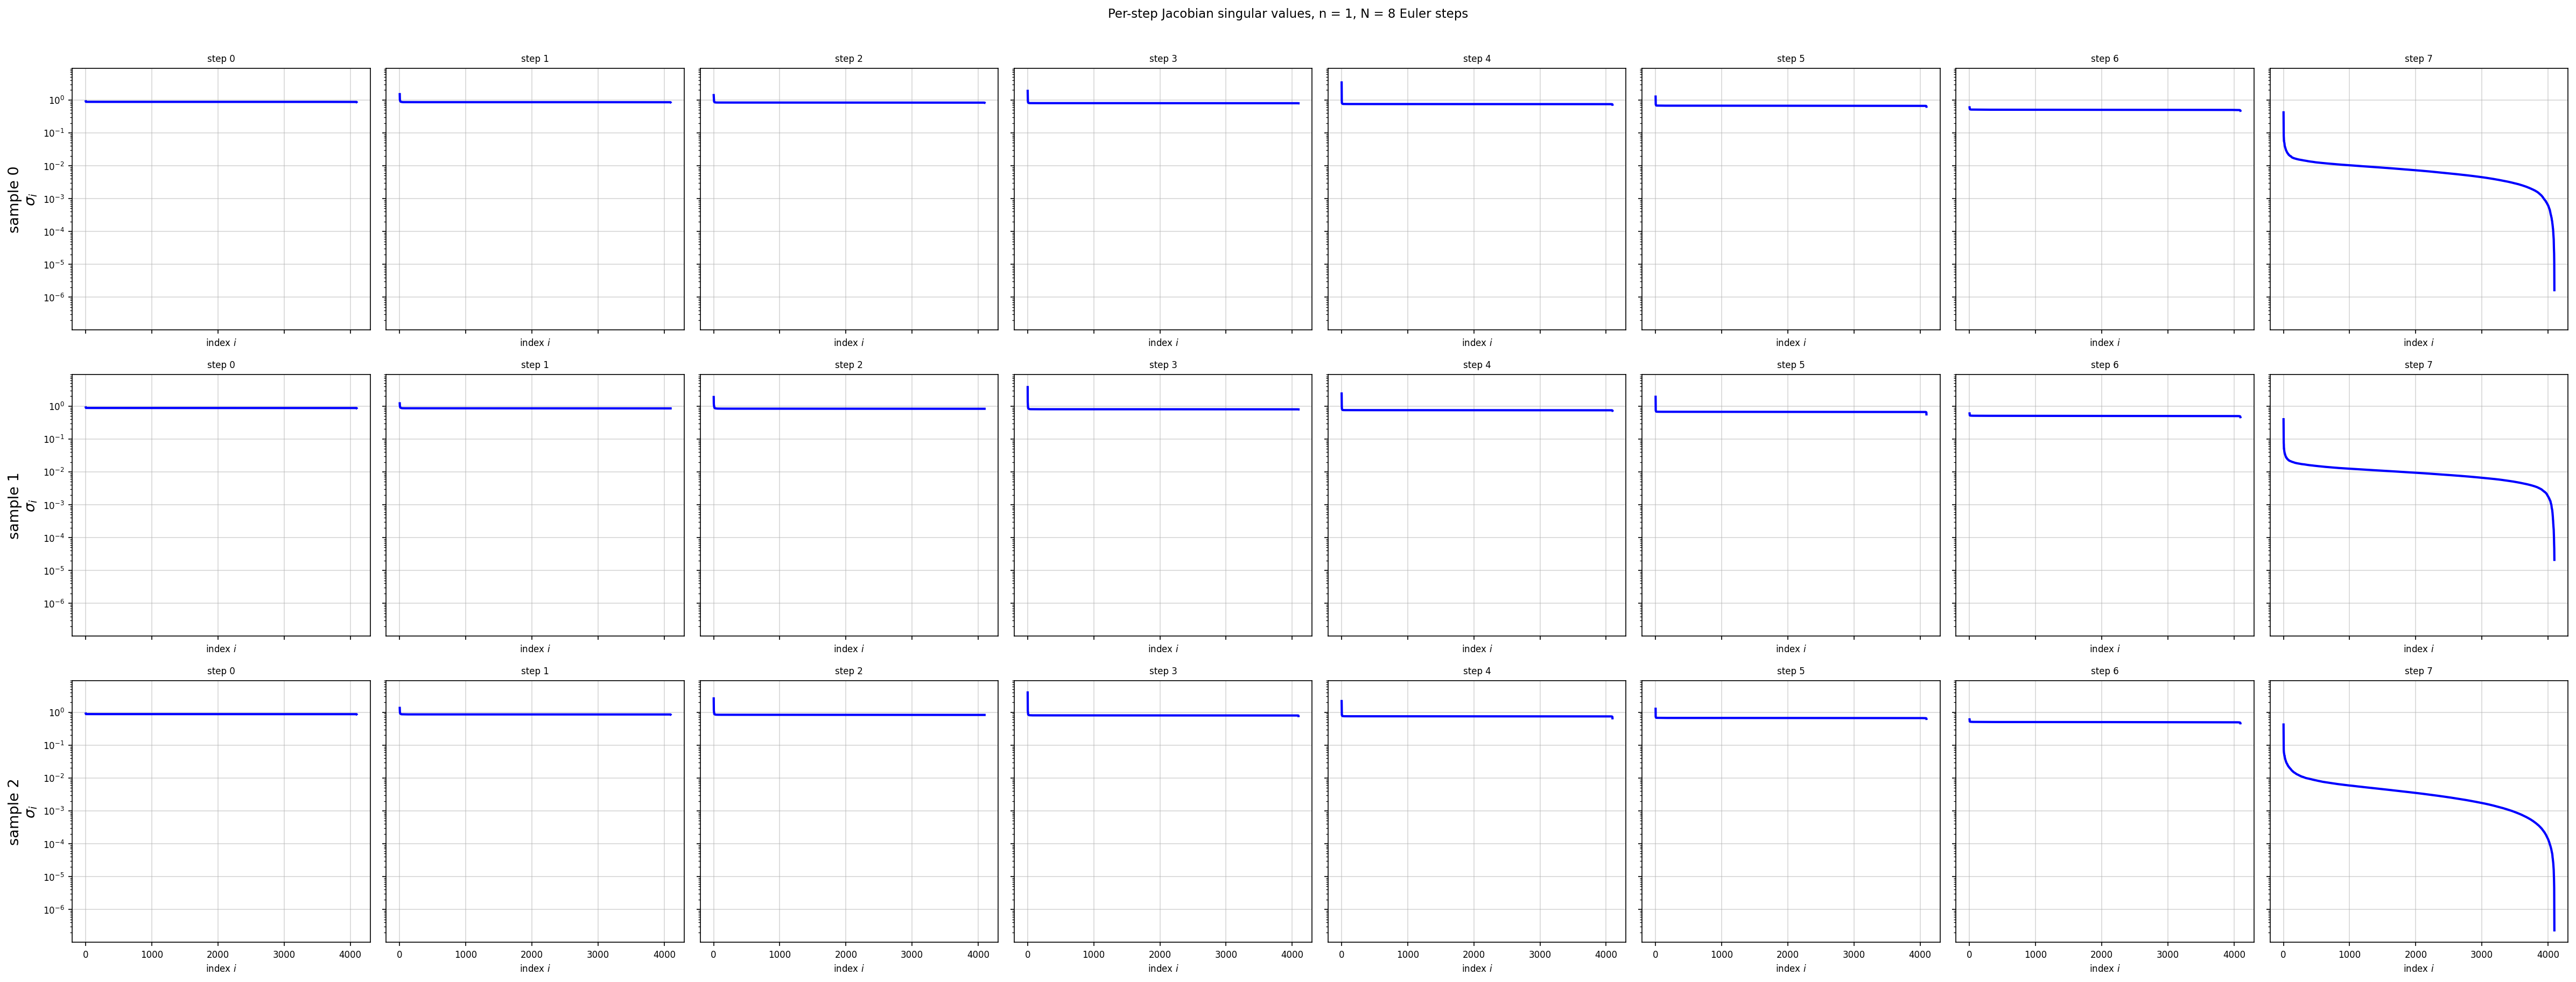

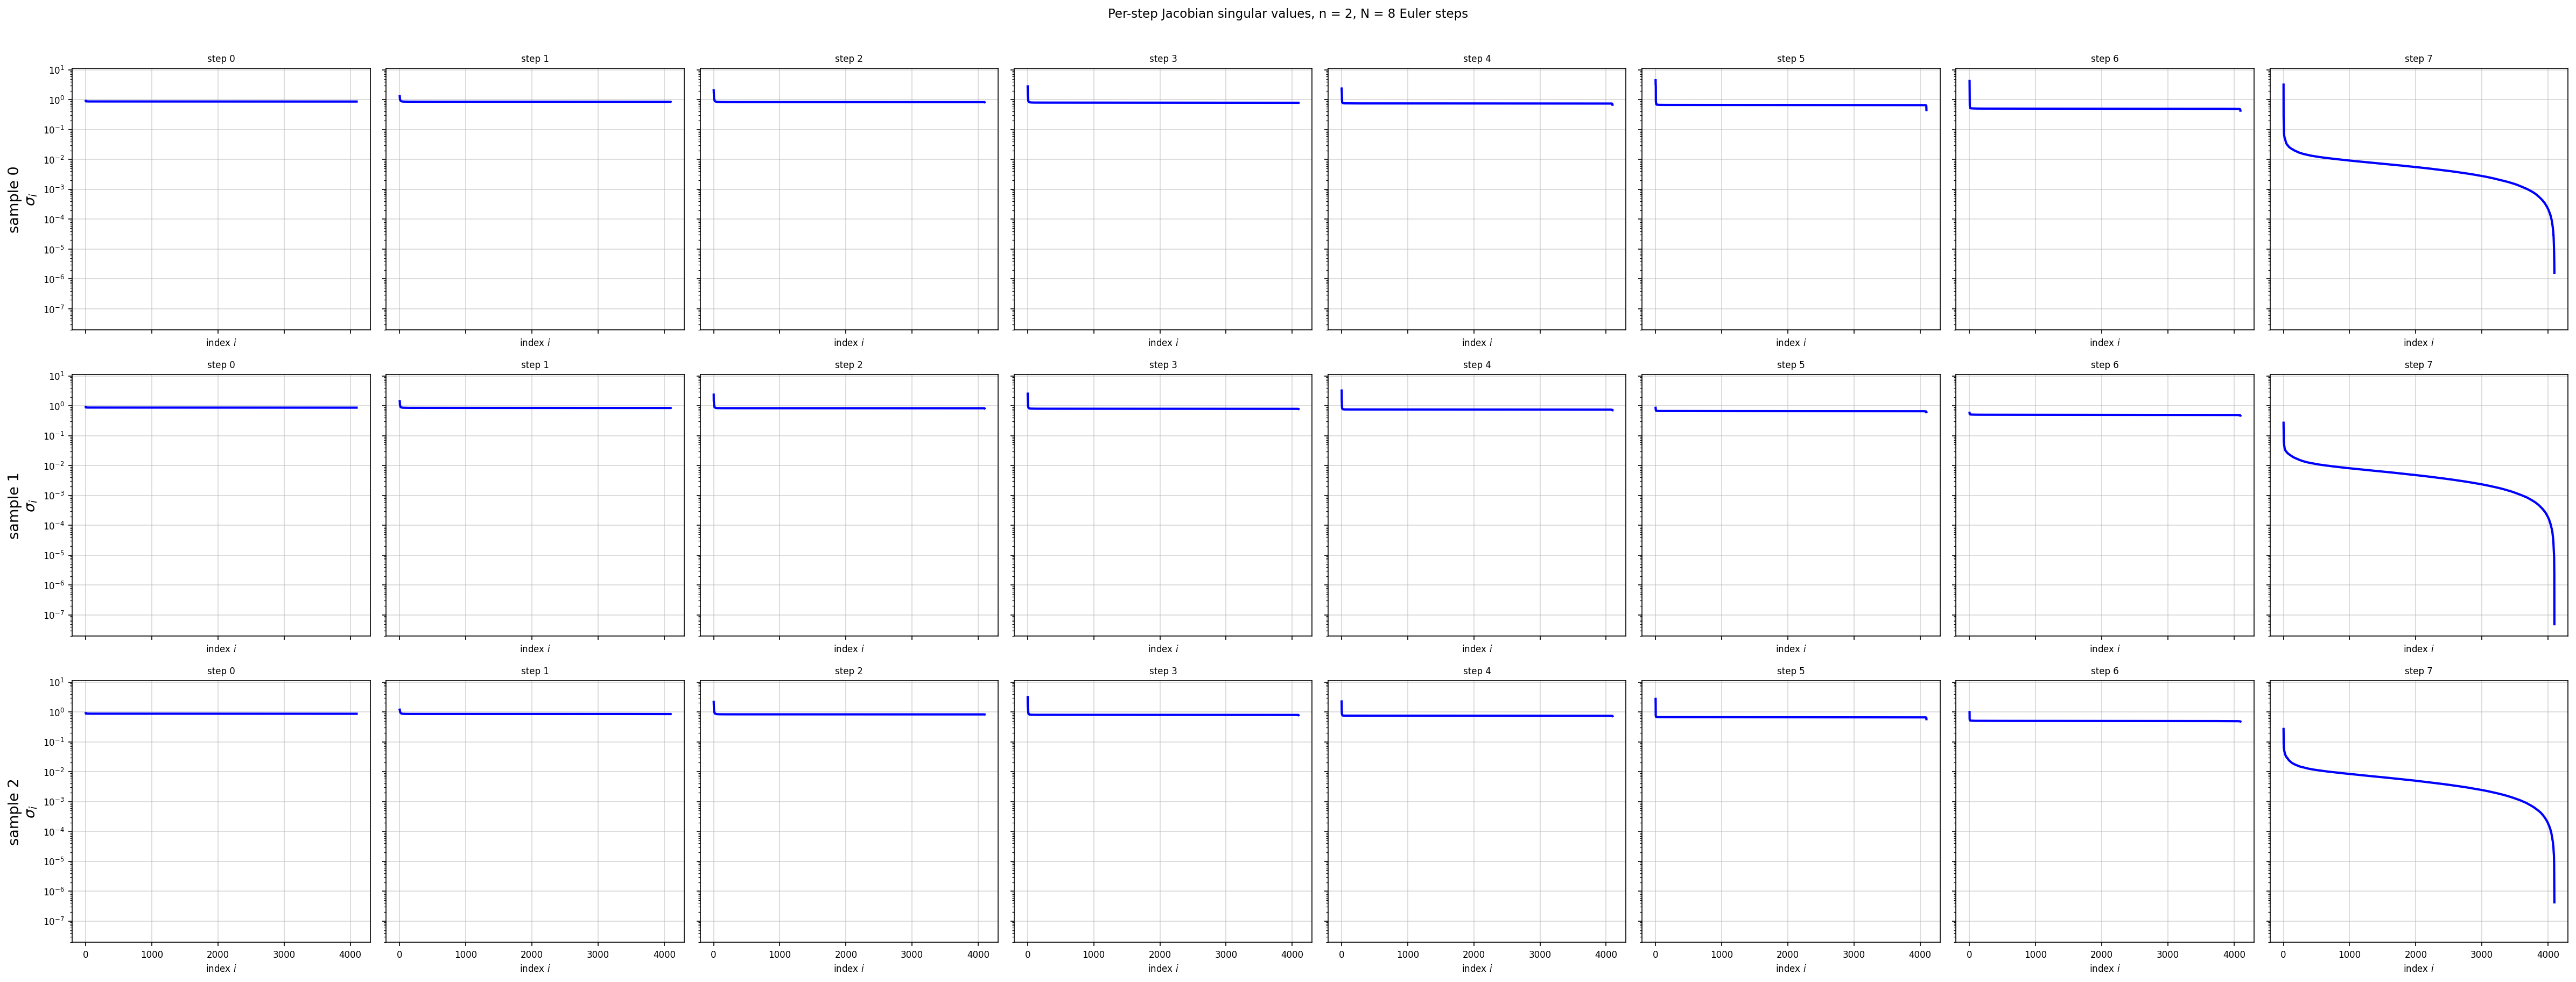

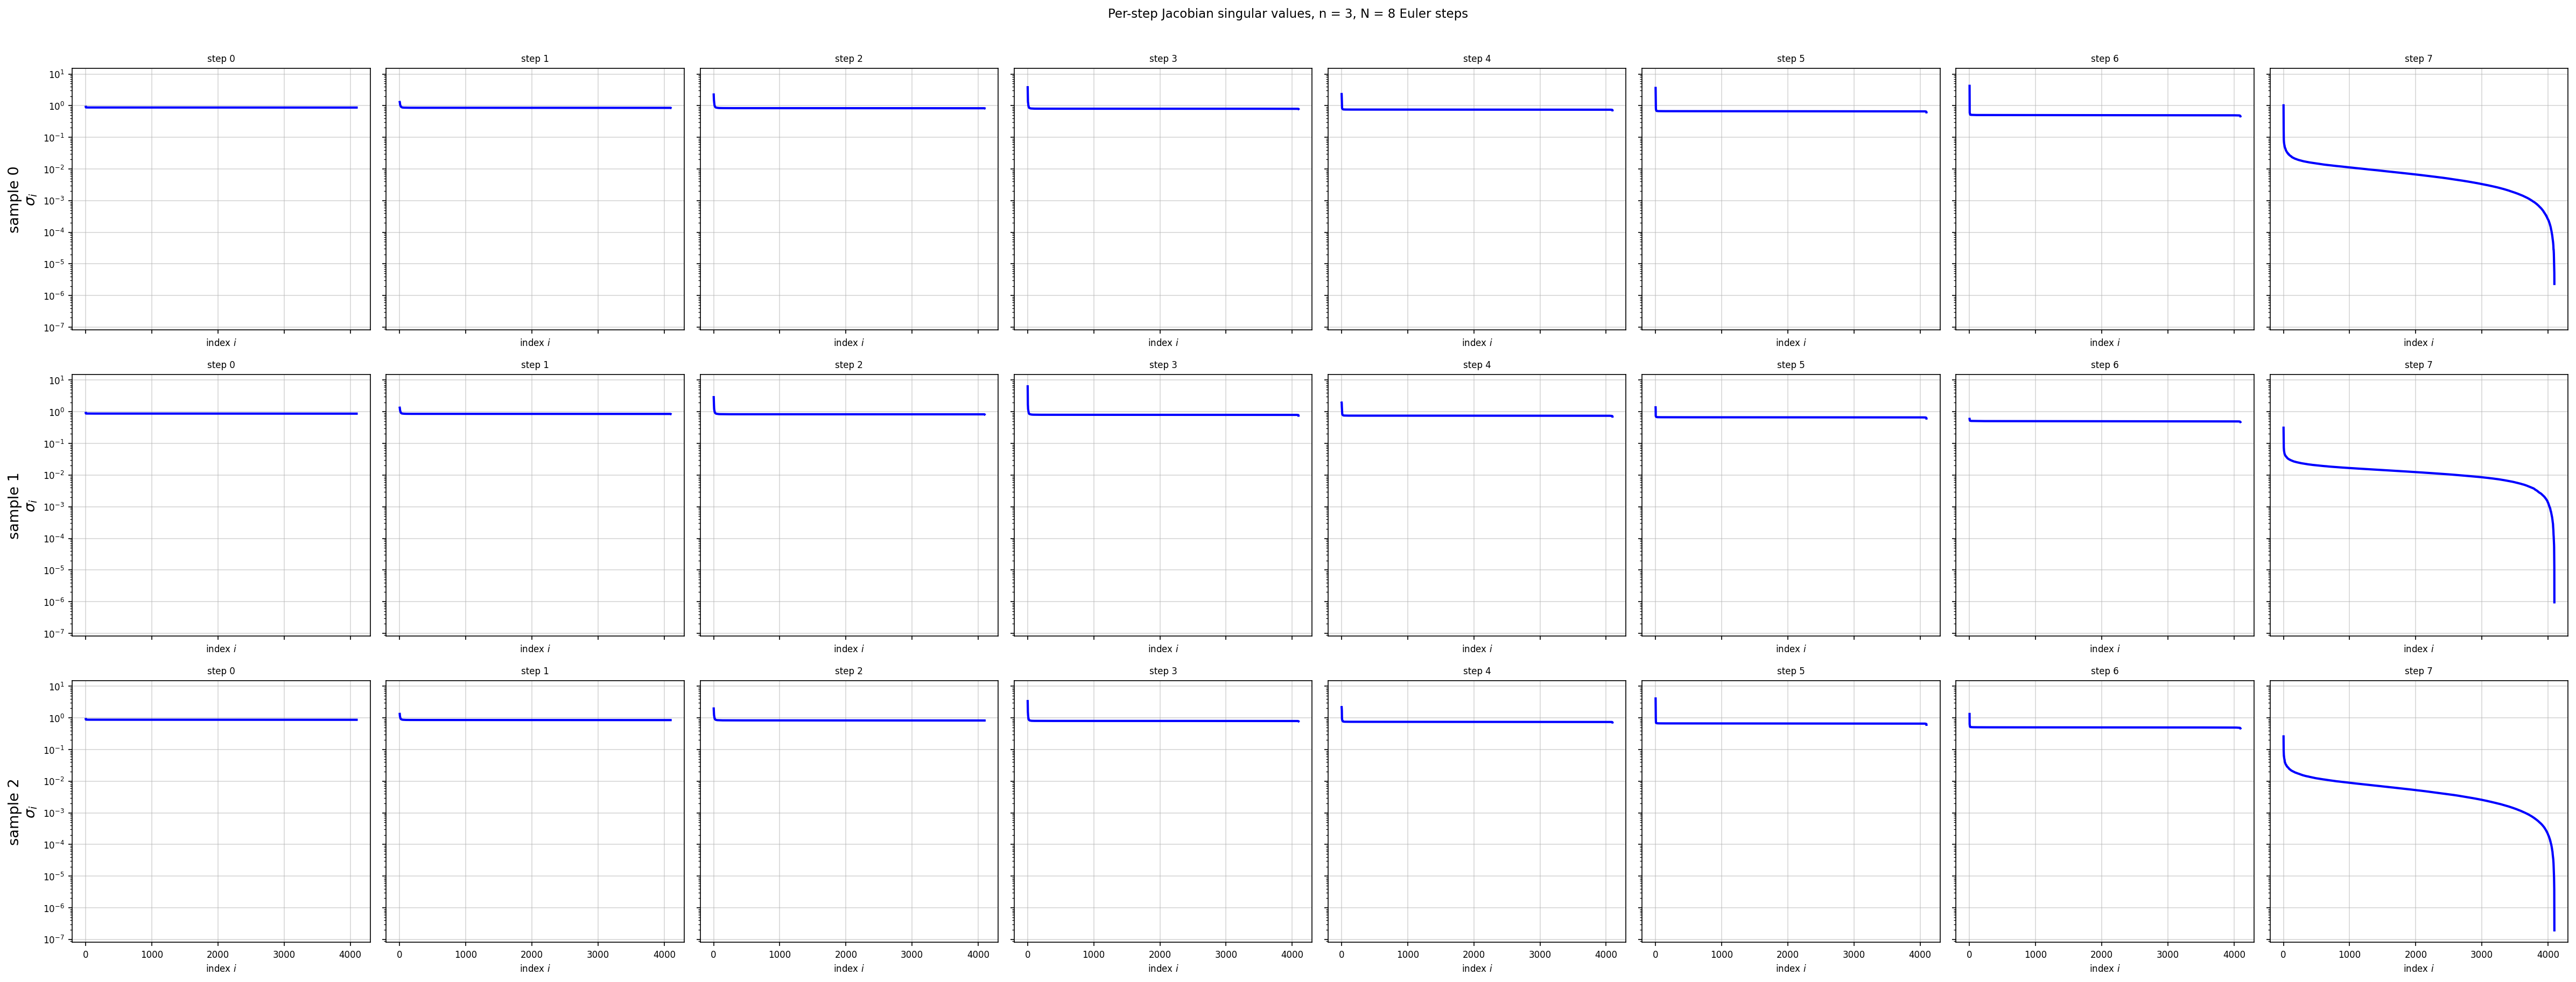

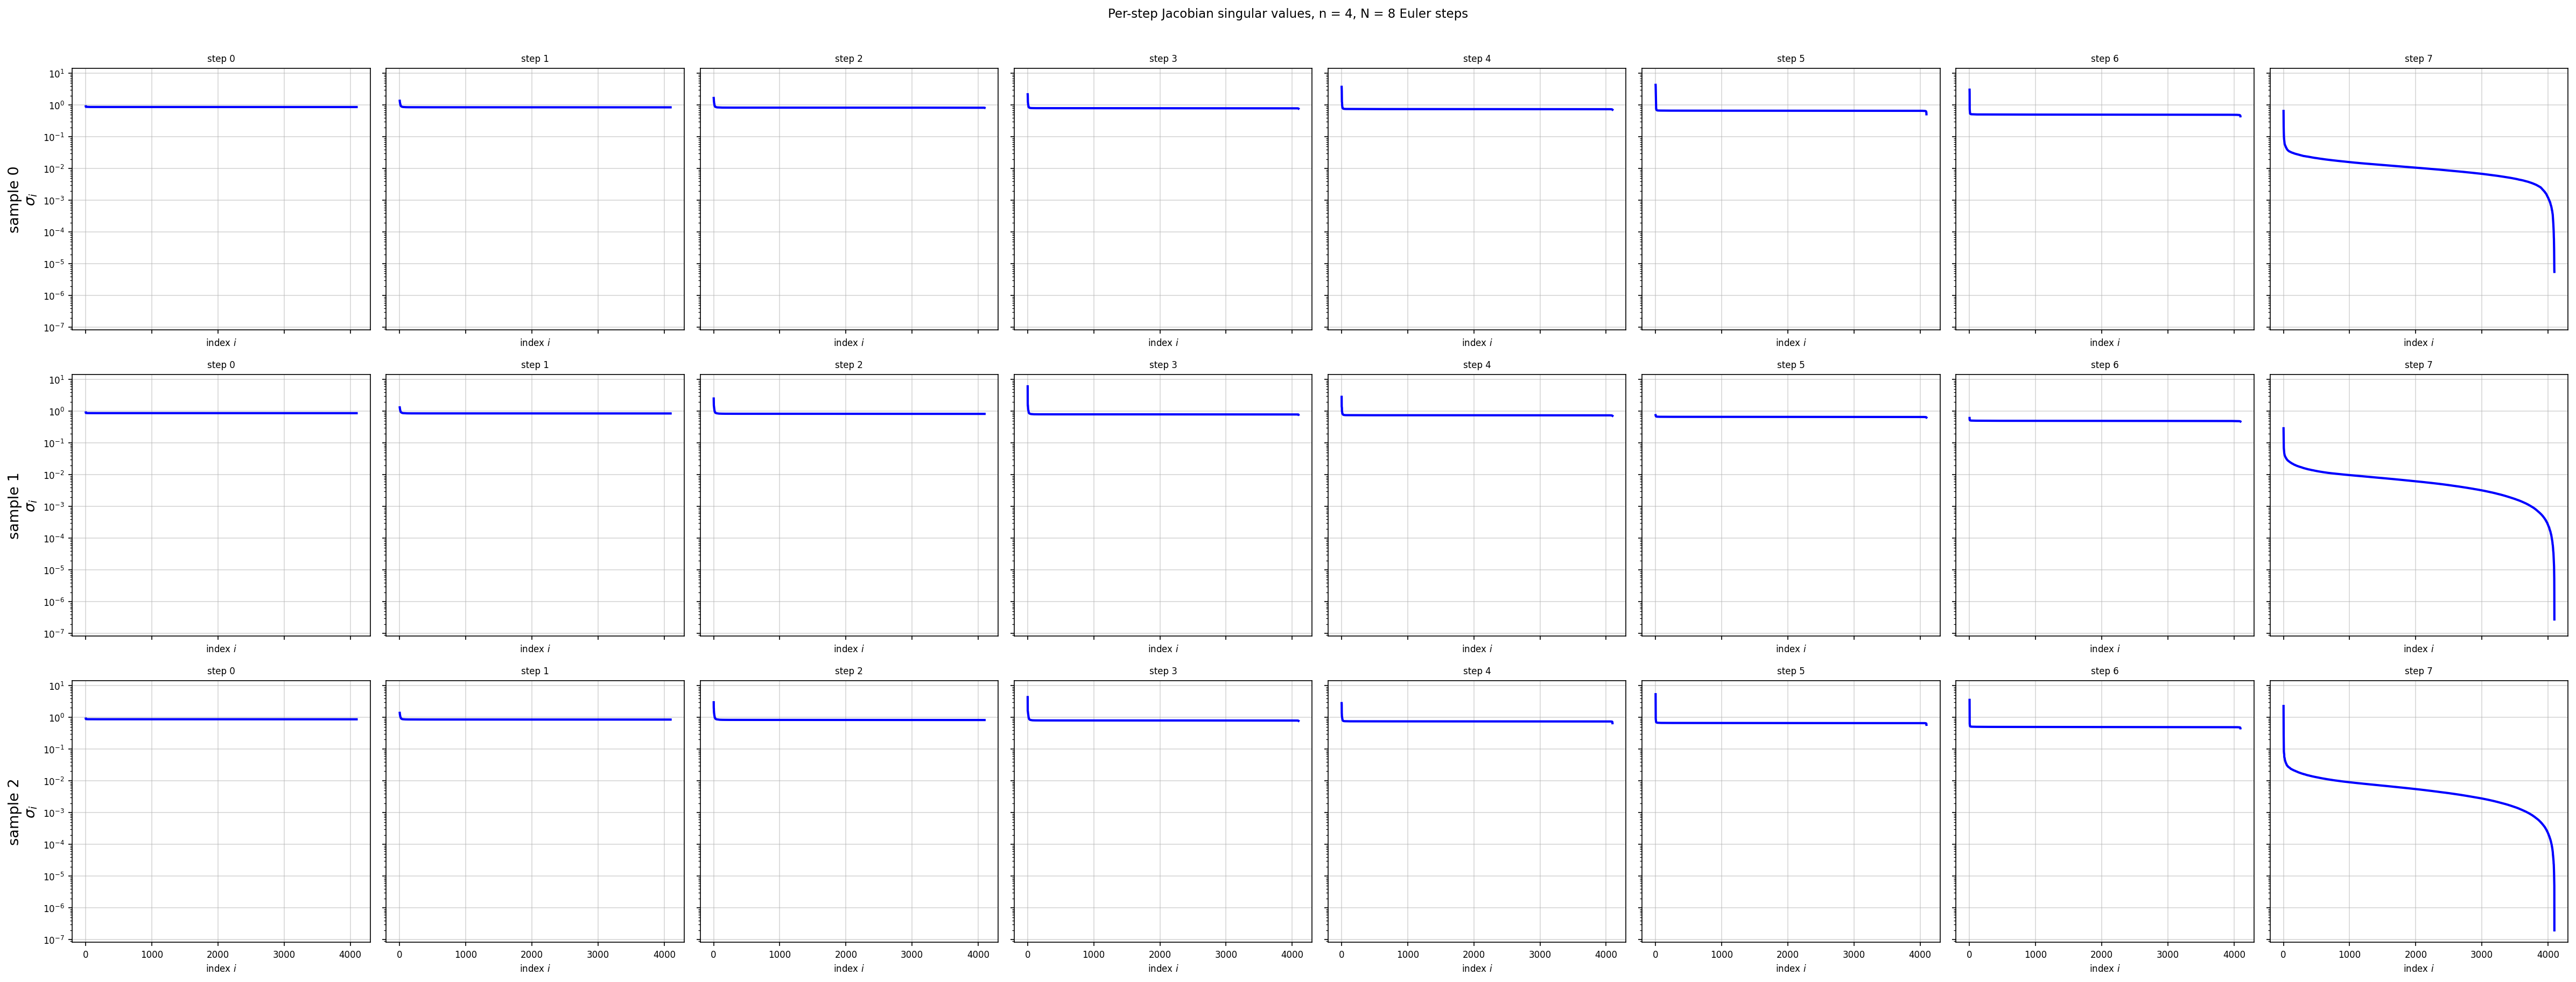

In [47]:
for n in N_VALUES:
    fig, axes = plt.subplots(NUM_SAMPLES_STEP, N_EULER,
                             figsize=(4 * N_EULER, 4 * NUM_SAMPLES_STEP),
                             facecolor="white",
                             sharex=True, sharey=True)
    if NUM_SAMPLES_STEP == 1:
        axes = axes[np.newaxis, :]

    cmap_steps = cmocean.cm.dense

    for k in range(NUM_SAMPLES_STEP):
        for i in range(N_EULER):
            ax = axes[k, i]
            s = per_step_svs[n][k][i].numpy()
            idx = np.arange(1, len(s) + 1)
            color = "blue"
            ax.semilogy(idx, s, color=color, lw=2)
            # ax.axhline(1.0, color="gray", ls="--", lw=0.8, alpha=0.8)
            ax.set_xlabel("index $i$", fontsize=8)
            if i == 0:
                ax.set_ylabel(f"sample {k}\n" + r"$\sigma_i$", fontsize=13)
            ax.set_title(f"step {i}", fontsize=8)
            ax.tick_params(labelsize=8)
            ax.set_yscale('log')

            ax.grid(True, alpha=0.5)

    fig.suptitle(f"Per-step Jacobian singular values, n = {n}, "
                 f"N = {N_EULER} Euler steps", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

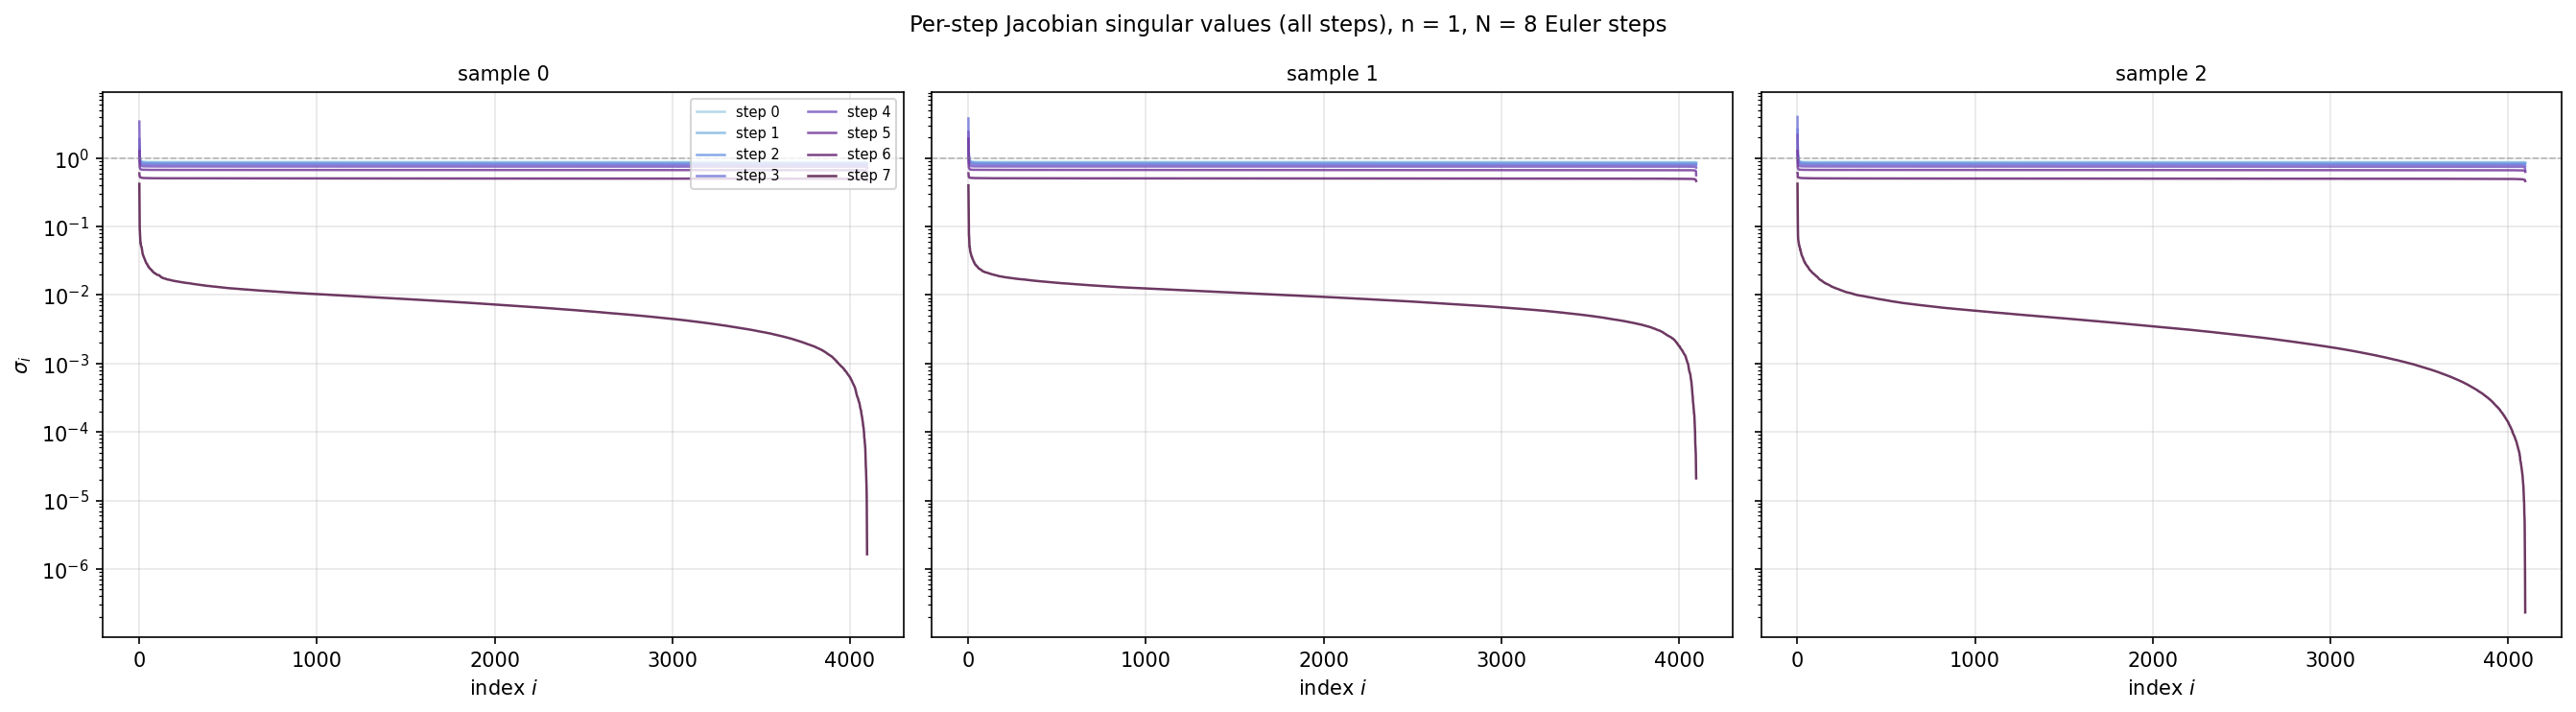

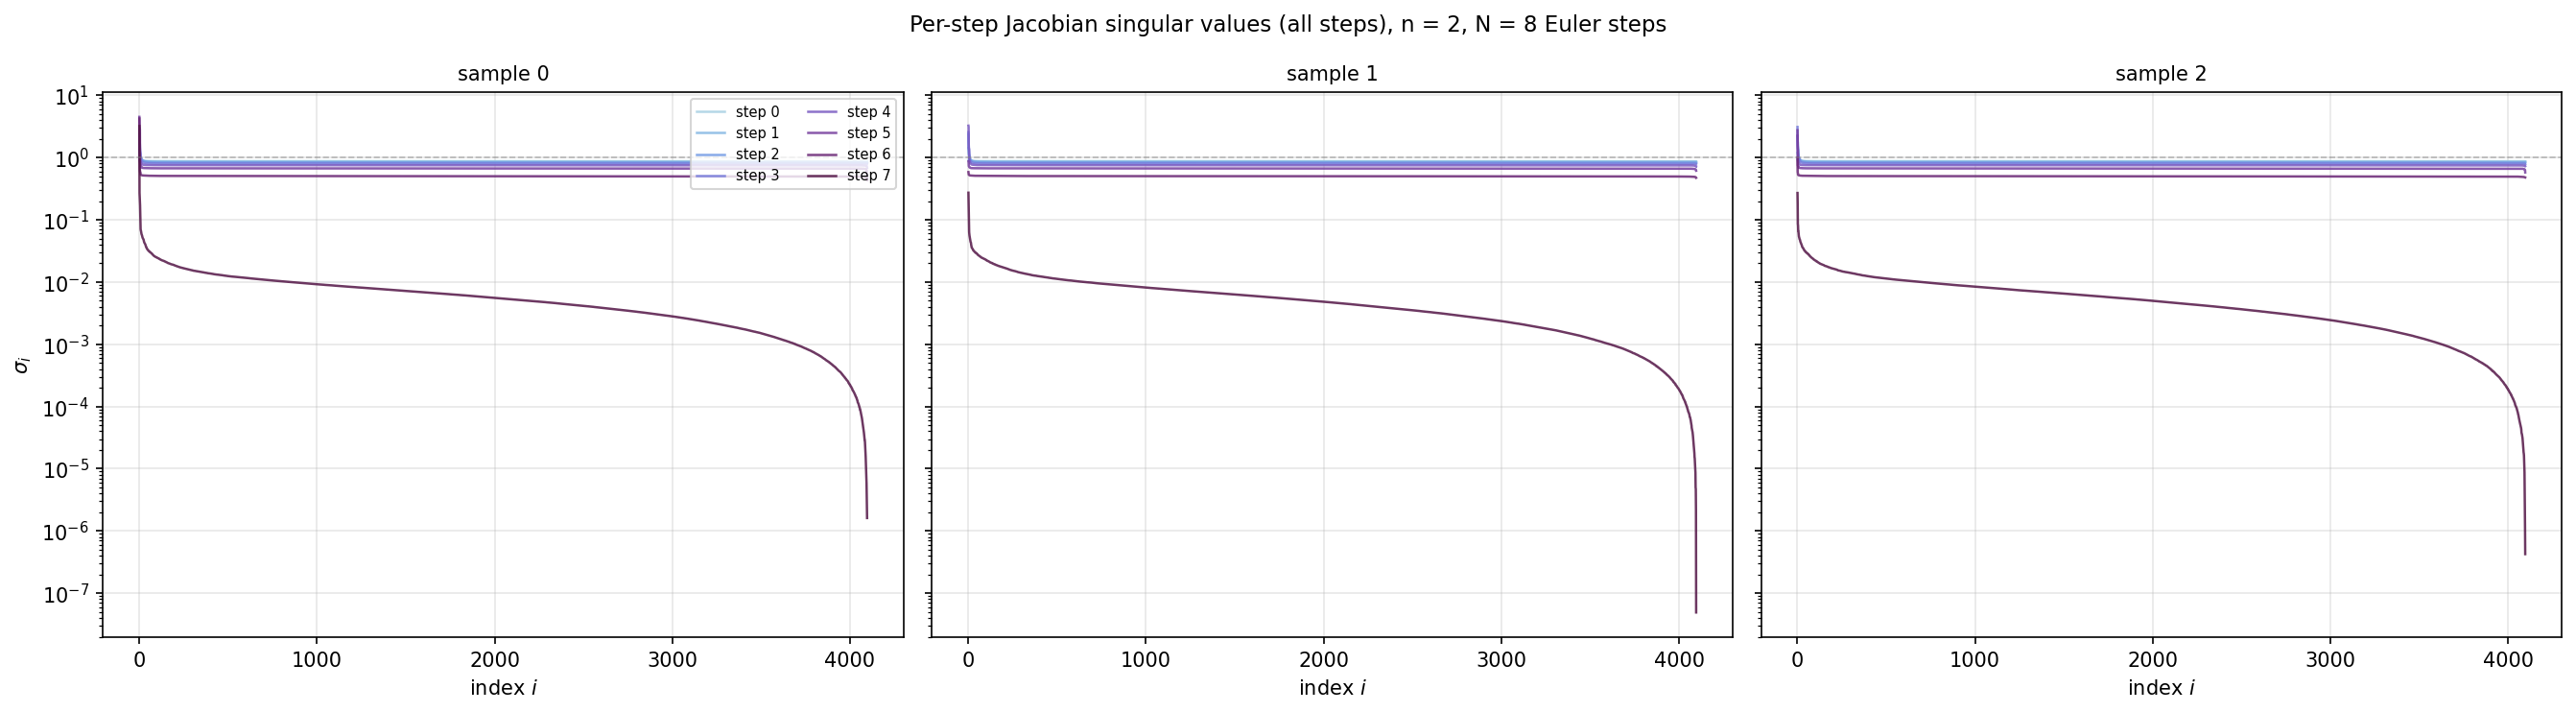

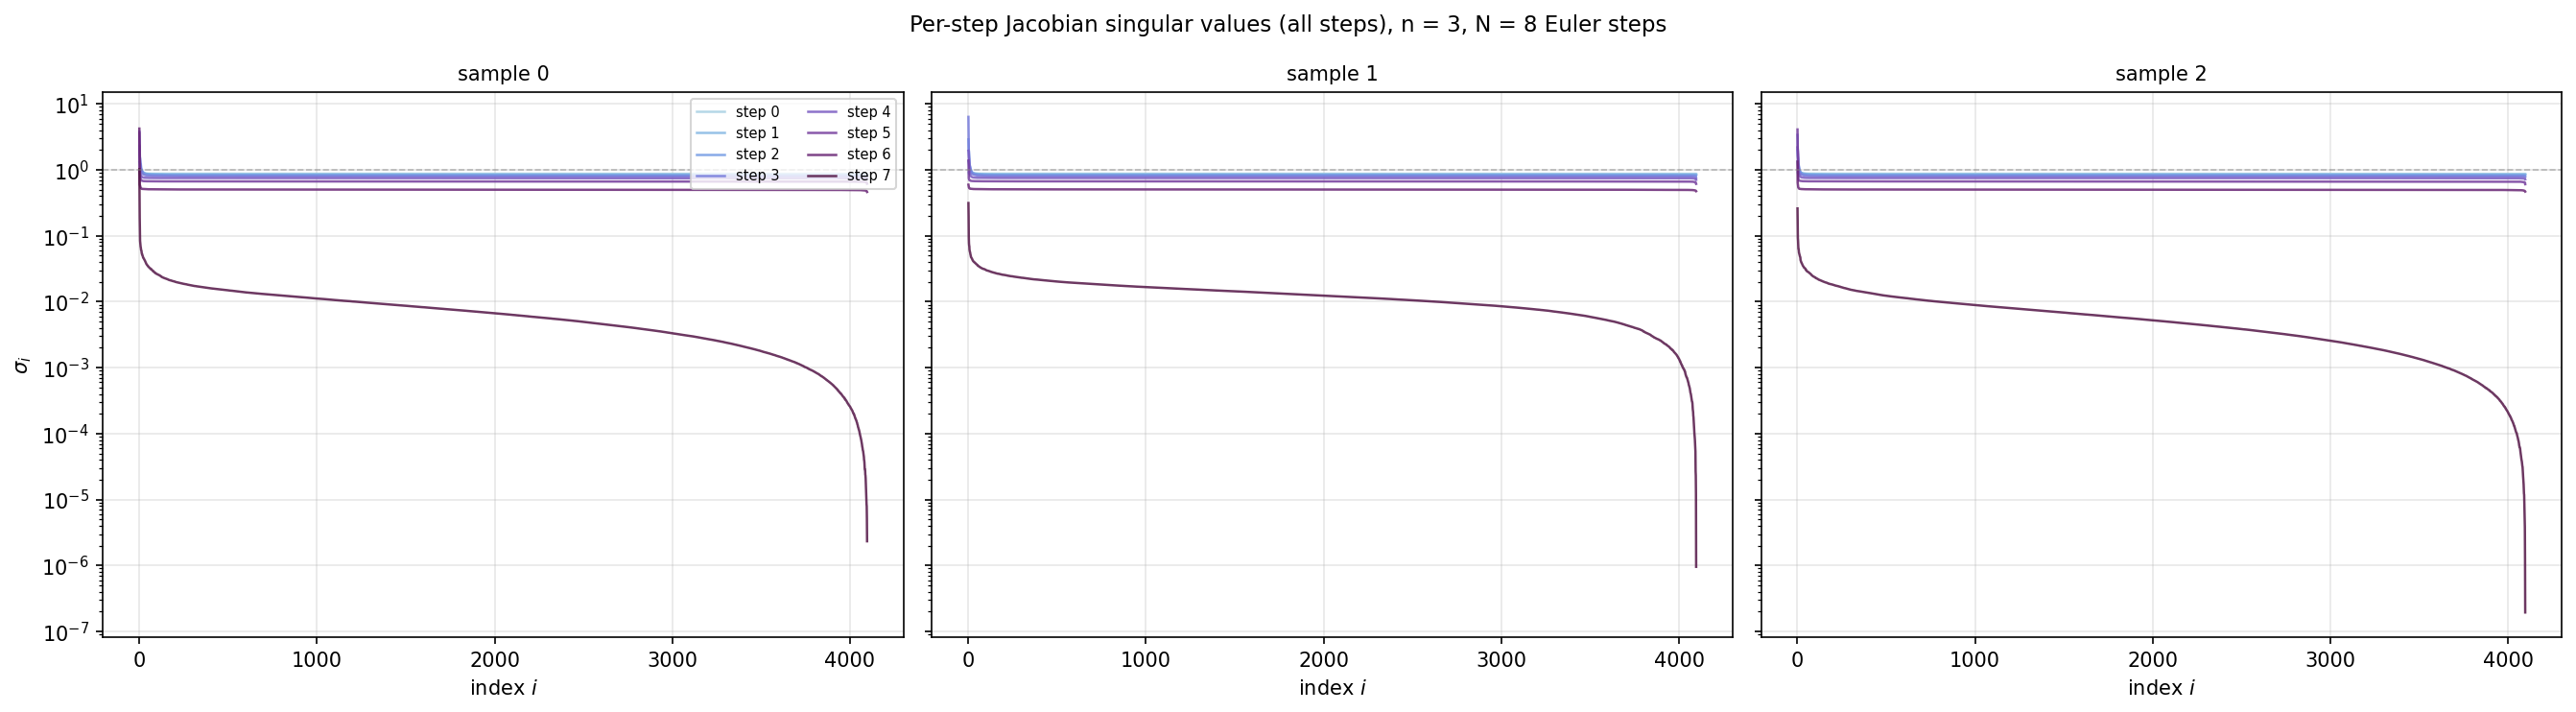

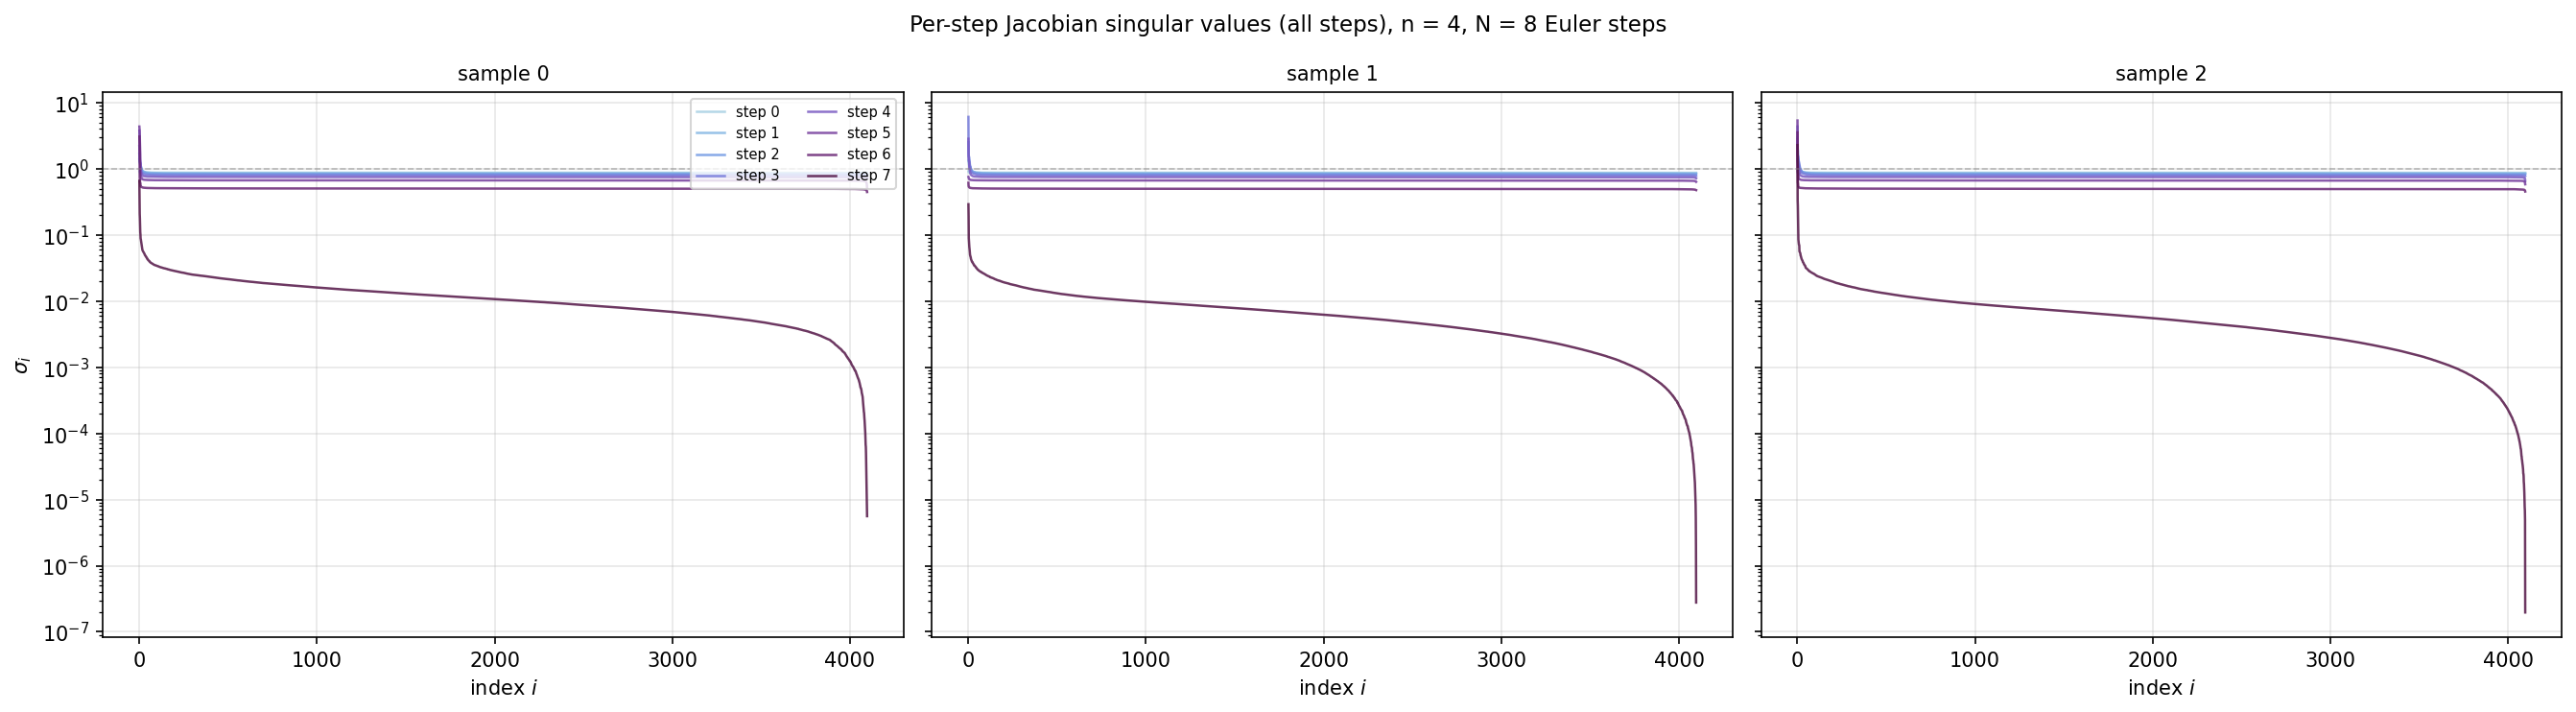

In [37]:
for n in N_VALUES:
    fig, axes = plt.subplots(1, NUM_SAMPLES_STEP,
                             figsize=(6 * NUM_SAMPLES_STEP, 5),
                             facecolor="white",
                             sharex=True, sharey=True)
    if NUM_SAMPLES_STEP == 1:
        axes = [axes]

    cmap_steps = cmocean.cm.dense

    for k in range(NUM_SAMPLES_STEP):
        ax = axes[k]
        for i, S in enumerate(per_step_svs[n][k]):
            s = S.numpy()
            idx = np.arange(1, len(s) + 1)
            color = cmap_steps(0.15 + 0.75 * i / (N_EULER - 1))
            ax.semilogy(idx, s, color=color, lw=1.2, alpha=0.85,
                        label=f"step {i}")
        ax.axhline(1.0, color="gray", ls="--", lw=0.8, alpha=0.5)
        ax.set_xlabel("index $i$")
        if k == 0:
            ax.set_ylabel(r"$\sigma_i$")
        ax.set_title(f"sample {k}", fontsize=10)
        ax.grid(True, alpha=0.3)

    axes[0].legend(fontsize=7, ncol=2, loc="upper right")
    fig.suptitle(f"Per-step Jacobian singular values (all steps), n = {n}, "
                 f"N = {N_EULER} Euler steps", fontsize=11)
    plt.tight_layout()
    plt.show()